#### Mount to Drive

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Add project folder to path (if needed for imports later)
import sys
sys.path.append('/content/drive/MyDrive/dales-bp-mech-interp/')

Mounted at /content/drive


#### Imports

In [3]:
# -*- coding: utf-8 -*-
"""HMM State Inference Task - Circuit Discovery Validation

Validates time-resolved circuit discovery methods on a discrete HMM task.
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import os
import pickle
from typing import Tuple, Dict, List

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

#### Device setup

In [5]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


#### Random seeds

In [6]:
# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

#### HMM data generation

In [7]:
class HMM:
    """Hidden Markov Model for sequence generation and inference.

    States: S = {A, B, C} (encoded as 0, 1, 2)
    Observations: O = {a, b, c} (encoded as 0, 1, 2)
    """

    def __init__(self, n_states=3, n_obs=3):
        self.n_states = n_states
        self.n_obs = n_obs

        # Transition matrix P(S_t | S_{t-1})
        # Diagonal-dominant: each state prefers to stay
        self.P_trans = np.array([
            [0.7, 0.2, 0.1],  # A → A/B/C
            [0.1, 0.7, 0.2],  # B → A/B/C
            [0.2, 0.1, 0.7]   # C → A/B/C
        ])

        # Emission matrix P(O_t | S_t)
        # Each state has a preferred observation
        self.P_emit = np.array([
            [0.8, 0.1, 0.1],  # A → a/b/c
            [0.1, 0.8, 0.1],  # B → a/b/c
            [0.1, 0.1, 0.8]   # C → a/b/c
        ])

        # Initial state distribution (uniform)
        self.P_init = np.ones(n_states) / n_states

    def generate_sequence(self, length: int) -> Tuple[np.ndarray, np.ndarray]:
        """Generate a single HMM sequence.

        Args:
            length: Sequence length

        Returns:
            states: (length,) array of hidden states
            observations: (length,) array of observations
        """
        states = np.zeros(length, dtype=int)
        observations = np.zeros(length, dtype=int)

        # Sample initial state
        states[0] = np.random.choice(self.n_states, p=self.P_init)
        observations[0] = np.random.choice(self.n_obs, p=self.P_emit[states[0]])

        # Generate sequence
        for t in range(1, length):
            # Sample next state
            states[t] = np.random.choice(self.n_states, p=self.P_trans[states[t-1]])
            # Sample observation
            observations[t] = np.random.choice(self.n_obs, p=self.P_emit[states[t]])

        return states, observations

    def generate_dataset(self, n_sequences: int, seq_length: int) -> Dict:
        """Generate dataset of HMM sequences.

        Args:
            n_sequences: Number of sequences
            seq_length: Length of each sequence

        Returns:
            Dictionary with observations, states, and one-hot encodings
        """
        all_states = np.zeros((n_sequences, seq_length), dtype=int)
        all_obs = np.zeros((n_sequences, seq_length), dtype=int)

        for i in range(n_sequences):
            states, obs = self.generate_sequence(seq_length)
            all_states[i] = states
            all_obs[i] = obs

        # One-hot encode observations for RNN input
        obs_onehot = np.eye(self.n_obs)[all_obs]  # (n_sequences, seq_length, n_obs)

        return {
            'states': all_states,
            'observations': all_obs,
            'obs_onehot': obs_onehot
        }

    def forward_inference(self, observations: np.ndarray) -> np.ndarray:
        """Forward algorithm for belief state computation.

        Args:
            observations: (seq_length,) array of observations

        Returns:
            alpha: (seq_length, n_states) array of P(S_t, O_1:t)
                   Normalize to get P(S_t | O_1:t)
        """
        T = len(observations)
        alpha = np.zeros((T, self.n_states))

        # Initialize
        alpha[0] = self.P_init * self.P_emit[:, observations[0]]
        alpha[0] /= alpha[0].sum()  # Normalize

        # Forward pass
        for t in range(1, T):
            for s in range(self.n_states):
                alpha[t, s] = self.P_emit[s, observations[t]] * \
                              (alpha[t-1] @ self.P_trans[:, s])
            alpha[t] /= alpha[t].sum()  # Normalize

        return alpha

    def generate_diagnostic_sequences(self, n_sequences: int, seq_length: int,
                                     pattern_type: str) -> Dict:
        """Generate sequences with controlled state dynamics.

        Args:
            n_sequences: Number of sequences
            seq_length: Length of each sequence
            pattern_type: 'maintain_A', 'maintain_B', 'maintain_C',
                         'transition_A_to_B', 'transition_B_to_C', 'transition_C_to_A'

        Returns:
            Dictionary with observations and states
        """
        all_states = np.zeros((n_sequences, seq_length), dtype=int)
        all_obs = np.zeros((n_sequences, seq_length), dtype=int)

        for i in range(n_sequences):
            if pattern_type == 'maintain_A':
                # Stay in state A
                states = np.zeros(seq_length, dtype=int)

            elif pattern_type == 'maintain_B':
                # Stay in state B
                states = np.ones(seq_length, dtype=int)

            elif pattern_type == 'maintain_C':
                # Stay in state C
                states = np.full(seq_length, 2, dtype=int)

            elif pattern_type == 'transition_A_to_B':
                # A for first half, transition to B at midpoint
                states = np.zeros(seq_length, dtype=int)
                mid = seq_length // 2
                states[mid:] = 1

            elif pattern_type == 'transition_B_to_C':
                # B for first half, transition to C at midpoint
                states = np.ones(seq_length, dtype=int)
                mid = seq_length // 2
                states[mid:] = 2

            elif pattern_type == 'transition_C_to_A':
                # C for first half, transition to A at midpoint
                states = np.full(seq_length, 2, dtype=int)
                mid = seq_length // 2
                states[mid:] = 0

            else:
                raise ValueError(f"Unknown pattern type: {pattern_type}")

            # Generate observations from states
            obs = np.array([np.random.choice(self.n_obs, p=self.P_emit[s])
                           for s in states])

            all_states[i] = states
            all_obs[i] = obs

        # One-hot encode
        obs_onehot = np.eye(self.n_obs)[all_obs]

        return {
            'states': all_states,
            'observations': all_obs,
            'obs_onehot': obs_onehot,
            'pattern_type': pattern_type
        }

In [8]:
class DeterministicHMM(HMM):
    """Near-deterministic HMM for cleaner circuit discovery validation."""

    def __init__(self):
        super().__init__(n_states=3, n_obs=3)

        # High persistence (90% stay)
        self.P_trans = np.array([
            [0.90, 0.07, 0.03],  # A → A/B/C
            [0.03, 0.90, 0.07],  # B → A/B/C
            [0.07, 0.03, 0.90]   # C → A/B/C
        ])

        # Near-deterministic emissions (95% reliability)
        self.P_emit = np.array([
            [0.95, 0.025, 0.025],  # A → a/b/c
            [0.025, 0.95, 0.025],  # B → a/b/c
            [0.025, 0.025, 0.95]   # C → a/b/c
        ])

#### Initialize HMM

In [9]:
# Initialize HMM
# hmm = HMM(n_states=3, n_obs=3)
hmm = DeterministicHMM()

In [10]:
# Generate training and test datasets
n_train = 2000
n_test = 1000
seq_length = 20

In [11]:
print("Generating datasets...")
train_data = hmm.generate_dataset(n_train, seq_length)
test_data = hmm.generate_dataset(n_test, seq_length)

print(f"Train: {n_train} sequences")
print(f"Test: {n_test} sequences")
print(f"Sequence length: {seq_length}")
print(f"Input shape: {train_data['obs_onehot'].shape}")
print(f"States shape: {train_data['states'].shape}")

Generating datasets...
Train: 2000 sequences
Test: 1000 sequences
Sequence length: 20
Input shape: (2000, 20, 3)
States shape: (2000, 20)


#### Verify HMM statistics

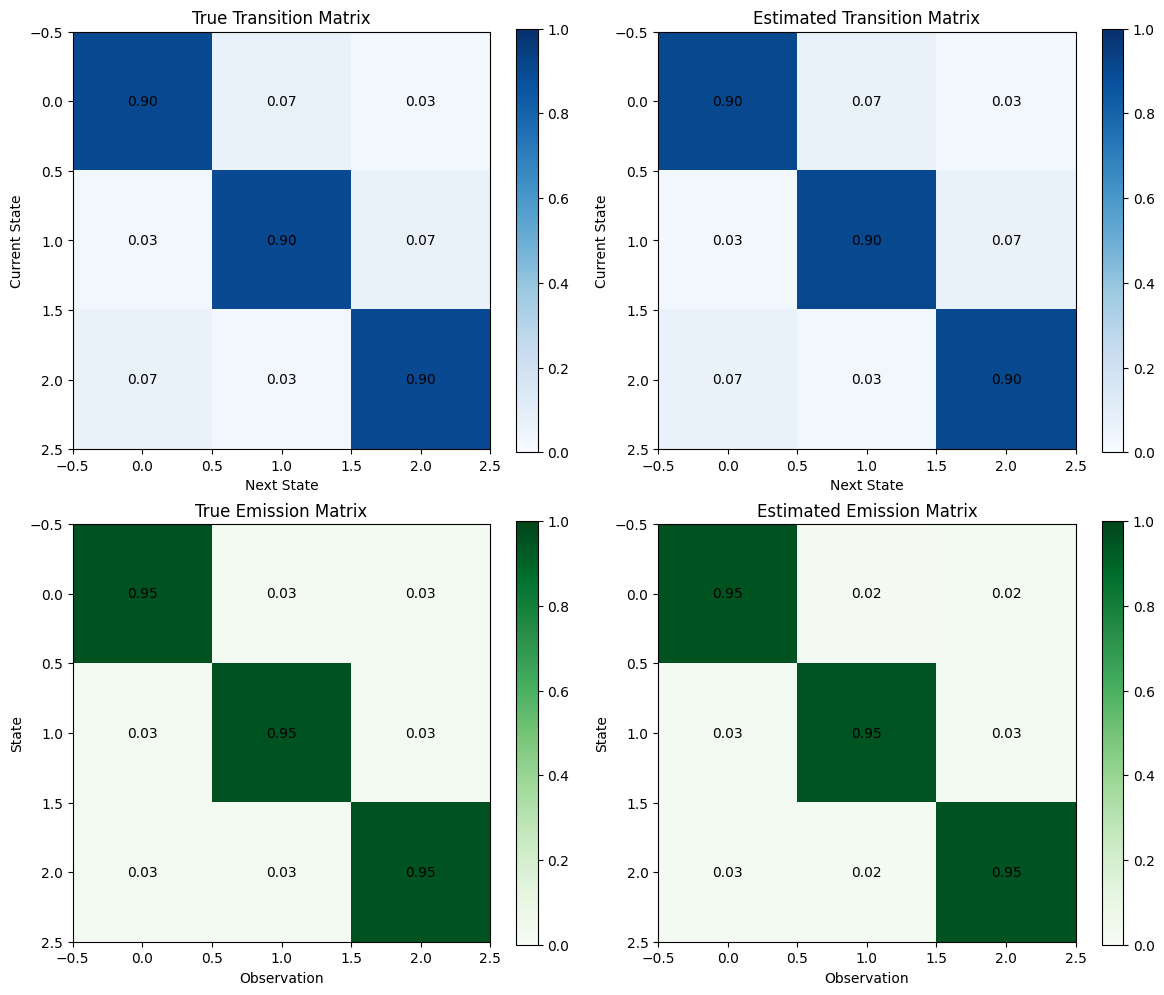


Transition matrix MAE: 0.0023
Emission matrix MAE: 0.0011

State frequencies: [0.3348   0.331525 0.333675]
Transition rate: 0.097 per timestep


In [12]:
# Verify transition and emission statistics from generated data
def verify_hmm_statistics(data: Dict, hmm: HMM):
    """Verify that generated data matches HMM parameters."""

    states = data['states']
    obs = data['observations']

    # Estimate transition matrix
    trans_counts = np.zeros((hmm.n_states, hmm.n_states))
    for seq in states:
        for t in range(len(seq) - 1):
            trans_counts[seq[t], seq[t+1]] += 1

    trans_est = trans_counts / trans_counts.sum(axis=1, keepdims=True)

    # Estimate emission matrix
    emit_counts = np.zeros((hmm.n_states, hmm.n_obs))
    for seq_s, seq_o in zip(states, obs):
        for s, o in zip(seq_s, seq_o):
            emit_counts[s, o] += 1

    emit_est = emit_counts / emit_counts.sum(axis=1, keepdims=True)

    # Plot comparison
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # True transition matrix
    im = axes[0, 0].imshow(hmm.P_trans, cmap='Blues', vmin=0, vmax=1)
    axes[0, 0].set_title('True Transition Matrix')
    axes[0, 0].set_xlabel('Next State')
    axes[0, 0].set_ylabel('Current State')
    for i in range(3):
        for j in range(3):
            axes[0, 0].text(j, i, f'{hmm.P_trans[i,j]:.2f}',
                          ha='center', va='center')
    plt.colorbar(im, ax=axes[0, 0])

    # Estimated transition matrix
    im = axes[0, 1].imshow(trans_est, cmap='Blues', vmin=0, vmax=1)
    axes[0, 1].set_title('Estimated Transition Matrix')
    axes[0, 1].set_xlabel('Next State')
    axes[0, 1].set_ylabel('Current State')
    for i in range(3):
        for j in range(3):
            axes[0, 1].text(j, i, f'{trans_est[i,j]:.2f}',
                          ha='center', va='center')
    plt.colorbar(im, ax=axes[0, 1])

    # True emission matrix
    im = axes[1, 0].imshow(hmm.P_emit, cmap='Greens', vmin=0, vmax=1)
    axes[1, 0].set_title('True Emission Matrix')
    axes[1, 0].set_xlabel('Observation')
    axes[1, 0].set_ylabel('State')
    for i in range(3):
        for j in range(3):
            axes[1, 0].text(j, i, f'{hmm.P_emit[i,j]:.2f}',
                          ha='center', va='center')
    plt.colorbar(im, ax=axes[1, 0])

    # Estimated emission matrix
    im = axes[1, 1].imshow(emit_est, cmap='Greens', vmin=0, vmax=1)
    axes[1, 1].set_title('Estimated Emission Matrix')
    axes[1, 1].set_xlabel('Observation')
    axes[1, 1].set_ylabel('State')
    for i in range(3):
        for j in range(3):
            axes[1, 1].text(j, i, f'{emit_est[i,j]:.2f}',
                          ha='center', va='center')
    plt.colorbar(im, ax=axes[1, 1])

    plt.tight_layout()
    plt.show()

    # Compute errors
    trans_error = np.abs(hmm.P_trans - trans_est).mean()
    emit_error = np.abs(hmm.P_emit - emit_est).mean()

    print(f"\nTransition matrix MAE: {trans_error:.4f}")
    print(f"Emission matrix MAE: {emit_error:.4f}")

    # State occupancy
    state_counts = np.bincount(states.ravel(), minlength=hmm.n_states)
    state_freq = state_counts / state_counts.sum()
    print(f"\nState frequencies: {state_freq}")

    # Transition frequency
    n_transitions = (states[:, 1:] != states[:, :-1]).sum()
    transition_rate = n_transitions / (states.size - states.shape[0])
    print(f"Transition rate: {transition_rate:.3f} per timestep")

verify_hmm_statistics(train_data, hmm)

#### Visualize example sequences

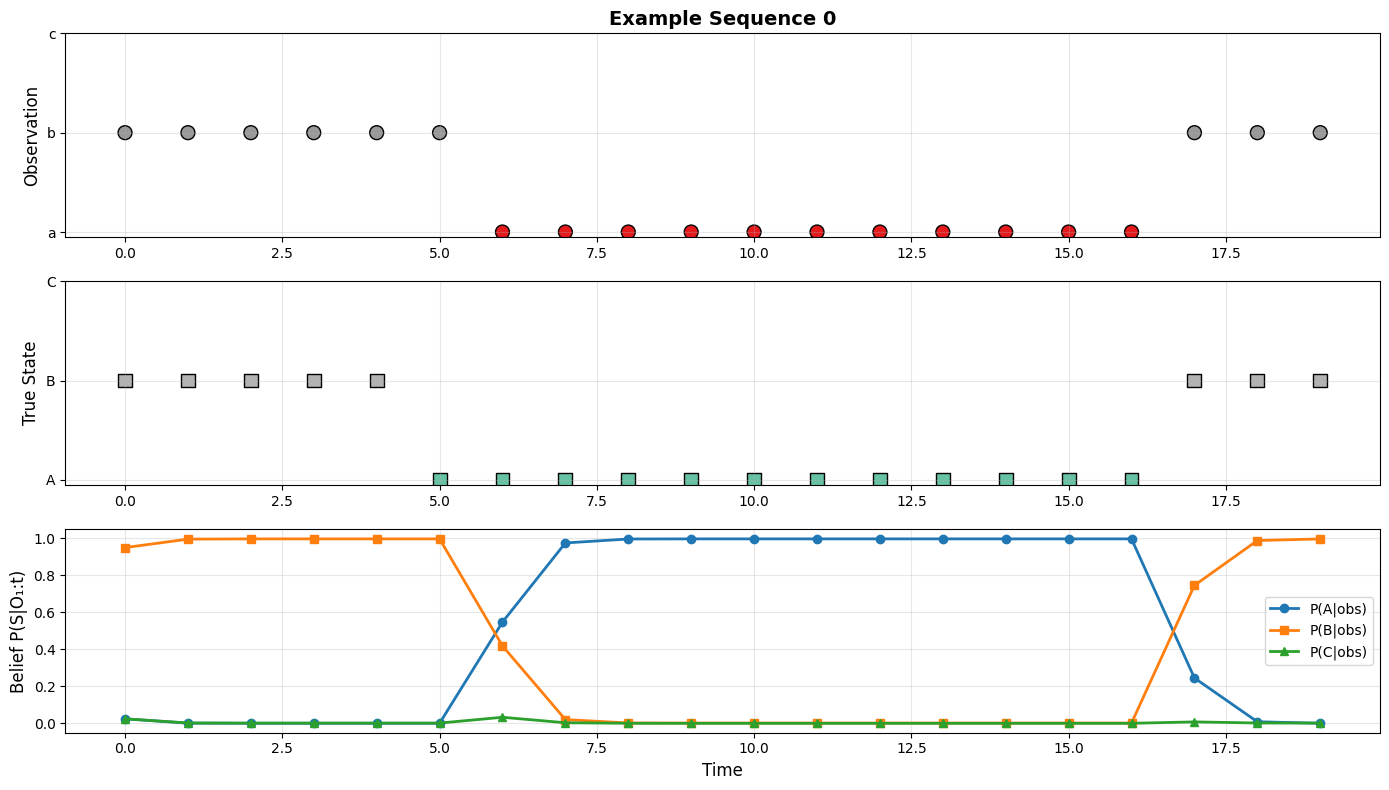

Sequence length: 20
Number of state transitions: 2
Observations: [1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 1]
True states:  [1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1]


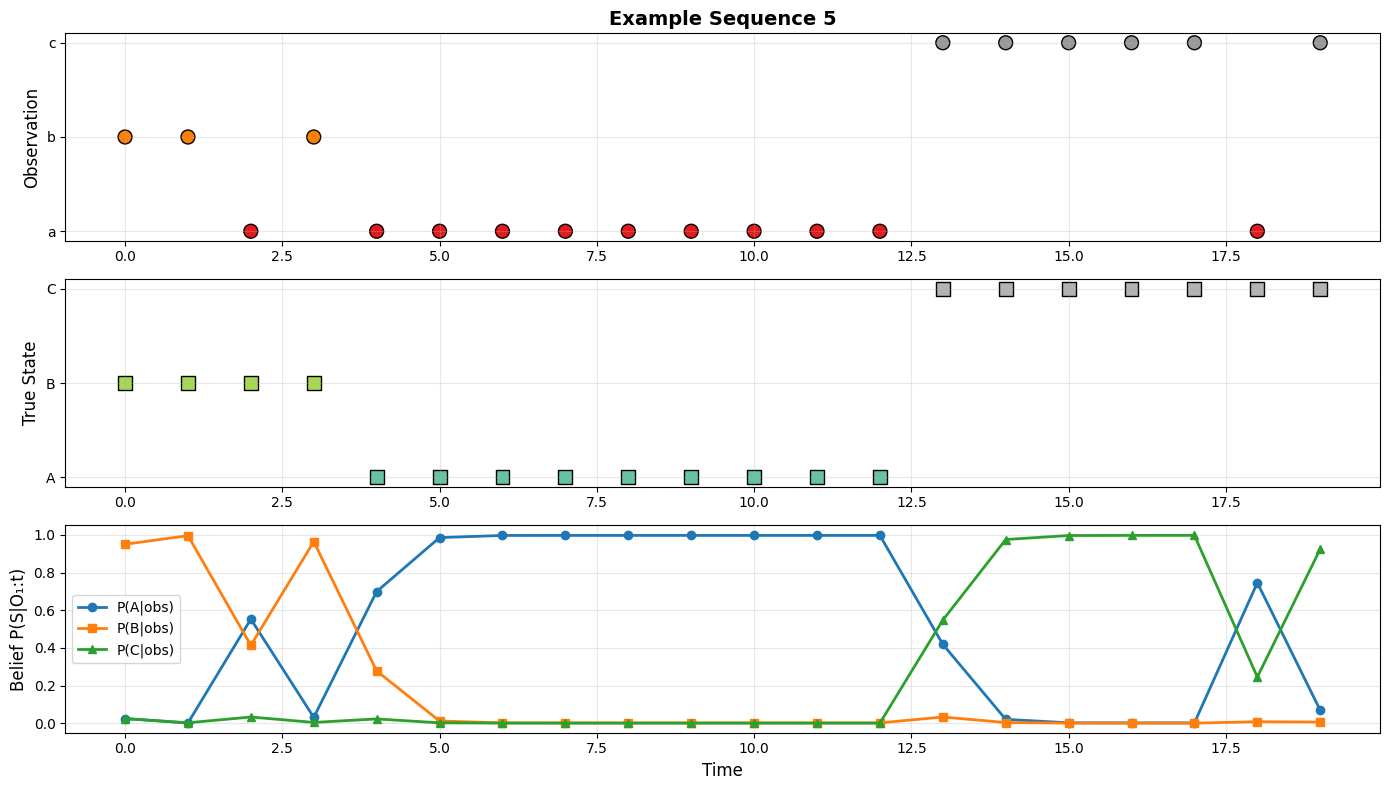

Sequence length: 20
Number of state transitions: 2
Observations: [1 1 0 1 0 0 0 0 0 0 0 0 0 2 2 2 2 2 0 2]
True states:  [1 1 1 1 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2]


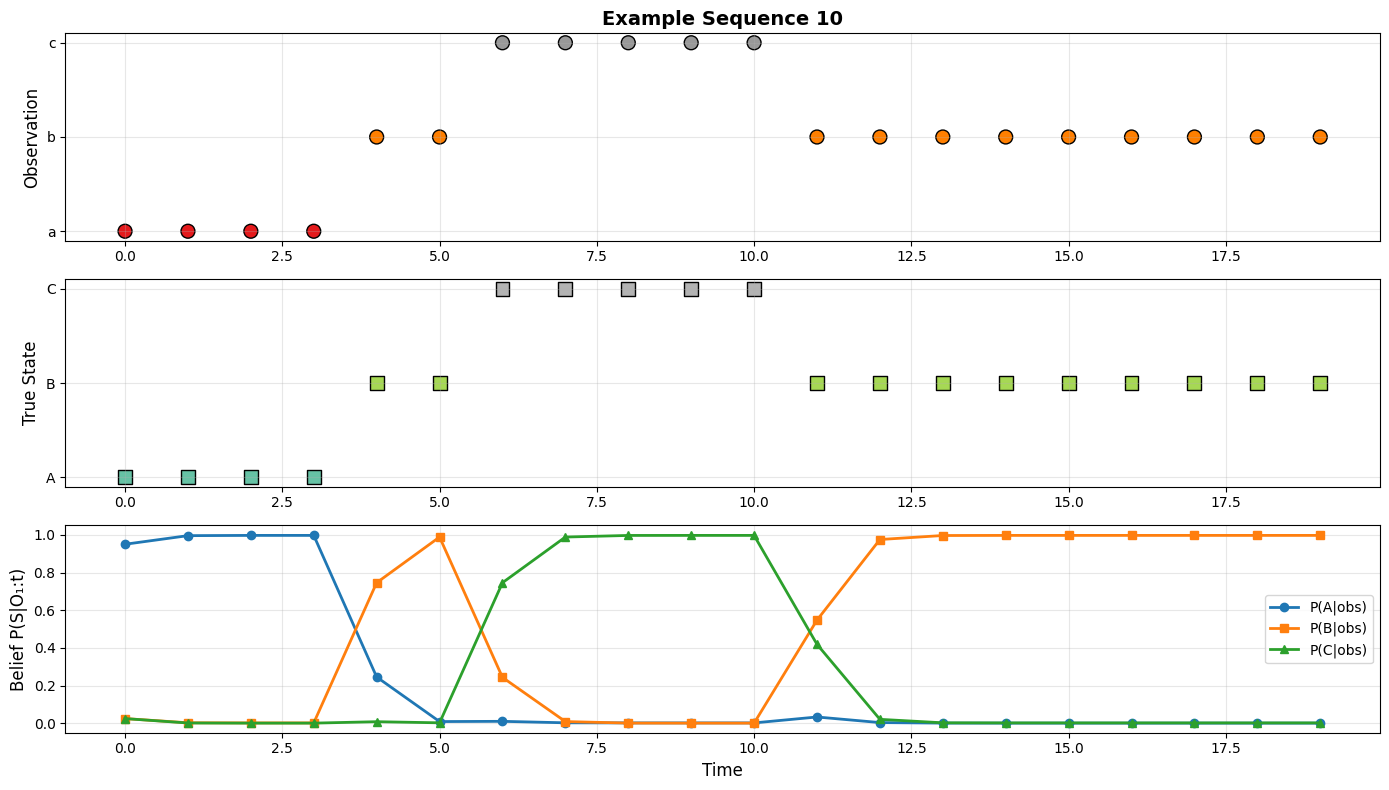

Sequence length: 20
Number of state transitions: 3
Observations: [0 0 0 0 1 1 2 2 2 2 2 1 1 1 1 1 1 1 1 1]
True states:  [0 0 0 0 1 1 2 2 2 2 2 1 1 1 1 1 1 1 1 1]


In [13]:
# Visualize example sequences with belief states
def plot_sequence_with_beliefs(hmm: HMM, seq_idx: int, data: Dict):
    """Plot an example sequence with observations, true states, and belief states."""

    obs = data['observations'][seq_idx]
    states = data['states'][seq_idx]

    # Compute belief states using forward algorithm
    beliefs = hmm.forward_inference(obs)

    fig, axes = plt.subplots(3, 1, figsize=(14, 8))

    # Plot observations
    ax = axes[0]
    ax.scatter(range(len(obs)), obs, c=obs, cmap='Set1', s=100, edgecolors='black')
    ax.set_ylabel('Observation', fontsize=12)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['a', 'b', 'c'])
    ax.set_title(f'Example Sequence {seq_idx}', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)

    # Plot true hidden states
    ax = axes[1]
    ax.scatter(range(len(states)), states, c=states, cmap='Set2', s=100,
              edgecolors='black', marker='s')
    ax.set_ylabel('True State', fontsize=12)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['A', 'B', 'C'])
    ax.grid(alpha=0.3)

    # Plot belief states
    ax = axes[2]
    times = range(len(beliefs))
    ax.plot(times, beliefs[:, 0], 'o-', label='P(A|obs)', linewidth=2, markersize=6)
    ax.plot(times, beliefs[:, 1], 's-', label='P(B|obs)', linewidth=2, markersize=6)
    ax.plot(times, beliefs[:, 2], '^-', label='P(C|obs)', linewidth=2, markersize=6)
    ax.set_xlabel('Time', fontsize=12)
    ax.set_ylabel('Belief P(S|O₁:t)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)
    ax.set_ylim([-0.05, 1.05])

    plt.tight_layout()
    plt.show()

    # Print sequence info
    n_transitions = (states[1:] != states[:-1]).sum()
    print(f"Sequence length: {len(obs)}")
    print(f"Number of state transitions: {n_transitions}")
    print(f"Observations: {obs}")
    print(f"True states:  {states}")

# Plot a few examples
for i in [0, 5, 10]:
    plot_sequence_with_beliefs(hmm, i, train_data)

#### RNN Architecture

In [14]:
class SimpleRNN(nn.Module):
    """Simple RNN for HMM next-observation prediction.

    Architecture matches flip-flop models for consistency.
    No Dale's law constraints (conventional training).
    """

    def __init__(self, input_size, hidden_size, output_size, device):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.device = device
        self.output_size = output_size

        # RNN layer (tanh nonlinearity)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=1,
                         batch_first=True, nonlinearity='tanh')

        # Readout layer (logits for 3-way classification)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        """Forward pass with ReLU-clamped hidden states.

        Args:
            x: (batch, time, input_size) input observations

        Returns:
            pred: (batch, time, output_size) logits for next observation
            final_hidden: (batch, hidden_size) final hidden state
        """
        batch_size, n_steps, _ = x.shape

        # Initialize hidden state
        h0 = torch.zeros(1, batch_size, self.hidden_size).to(self.device)

        # Storage for outputs at each timestep
        pred = torch.zeros(batch_size, n_steps, self.output_size,
                          requires_grad=False).to(self.device)

        # Process sequence one step at a time (matching flip-flop architecture)
        for t in range(n_steps):
            x_t = x[:, t:t+1, :]  # (batch, 1, input_size)

            # RNN step
            out, h = self.rnn(x_t, h0)

            # Apply ReLU clamp (tanh → ReLU, matching flip-flop)
            h_clamped = torch.where(h > 0, h, torch.zeros_like(h))
            h0 = h_clamped

            # Readout for this timestep
            pred[:, t, :] = self.fc(h_clamped.squeeze(0))

        return pred, h_clamped.squeeze(0)

In [15]:
# Model hyperparameters (matching flip-flop setup)
input_size = 3      # One-hot observations {a, b, c}
hidden_size = 128   # Same as flip-flop models
output_size = 3     # Predict next observation {a, b, c}

#### Initialize RNN

In [16]:
# Initialize model
model = SimpleRNN(input_size, hidden_size, output_size, device).to(device)

print(f"Model architecture:")
print(f"  Input size: {input_size} (one-hot observations)")
print(f"  Hidden size: {hidden_size} neurons")
print(f"  Output size: {output_size} (next observation logits)")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nRNN weights:")
print(f"  W_ih: {model.rnn.weight_ih_l0.shape}")
print(f"  W_hh: {model.rnn.weight_hh_l0.shape}")
print(f"  Readout: {model.fc.weight.shape}")

Model architecture:
  Input size: 3 (one-hot observations)
  Hidden size: 128 neurons
  Output size: 3 (next observation logits)
  Total parameters: 17,411

RNN weights:
  W_ih: torch.Size([128, 3])
  W_hh: torch.Size([128, 128])
  Readout: torch.Size([3, 128])


#### Data loaders

In [17]:
def prepare_next_observation_targets(data: Dict) -> np.ndarray:
    """Create targets for next-observation prediction.

    Args:
        data: Dictionary with 'observations' key

    Returns:
        targets: (n_sequences, seq_length) with next observations
                 Last timestep uses same observation (no future to predict)
    """
    obs = data['observations']  # (n_sequences, seq_length)

    # Shift observations left by 1 (t → t+1)
    targets = np.zeros_like(obs)
    targets[:, :-1] = obs[:, 1:]  # Next observation
    targets[:, -1] = obs[:, -1]   # Last step: predict itself (ignored in loss)

    return targets

In [18]:
# Prepare targets
train_targets = prepare_next_observation_targets(train_data)
test_targets = prepare_next_observation_targets(test_data)

print(f"Target shapes:")
print(f"  Train: {train_targets.shape}")
print(f"  Test: {test_targets.shape}")

Target shapes:
  Train: (2000, 20)
  Test: (1000, 20)


In [19]:
# Verify alignment
seq_idx = 0
print(f"\nExample sequence {seq_idx}:")
print(f"  Observations: {train_data['observations'][seq_idx][:10]}")
print(f"  Targets:      {train_targets[seq_idx][:10]}")
print(f"  (Target at t should be observation at t+1)")


Example sequence 0:
  Observations: [1 1 1 1 1 1 0 0 0 0]
  Targets:      [1 1 1 1 1 0 0 0 0 0]
  (Target at t should be observation at t+1)


In [20]:
# Create PyTorch datasets
batch_size = 200

train_dataset = TensorDataset(
    torch.FloatTensor(train_data['obs_onehot']),
    torch.LongTensor(train_targets))
test_dataset = TensorDataset(
    torch.FloatTensor(test_data['obs_onehot']),
    torch.LongTensor(test_targets))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Test batches: {len(test_loader)}")


DataLoaders created:
  Train batches: 10
  Test batches: 5


#### RNN training

In [21]:
# Training hyperparameters
num_epochs = 150
learning_rate = 0.001

In [22]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [23]:
# Learning rate scheduler (optional, can help with convergence)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                  factor=0.5, patience=10)

In [24]:
# Storage for metrics
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

# Checkpoint epochs (for later circuit analysis at different training stages)
checkpoint_epochs = [10, 25, 50, 75, 100, 125, 150]

# Directory for saving
save_dir = '/content/drive/MyDrive/dales-bp-mech-interp/hmm_gt/'
os.makedirs(save_dir, exist_ok=True)

In [25]:
print(f"Starting training for {num_epochs} epochs...")
print(f"Optimizer: Adam (lr={learning_rate})")
print(f"Loss: CrossEntropyLoss")
print(f"Device: {device}")
print("="*60)

best_test_loss = float('inf')

for epoch in range(1, num_epochs + 1):
    # ============= TRAINING =============
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs, _ = model(inputs)  # (batch, time, 3)

        # Reshape for CrossEntropy: (batch*time, 3) and (batch*time)
        outputs_flat = outputs.reshape(-1, output_size)
        targets_flat = targets.reshape(-1)

        # Compute loss (excluding last timestep which has dummy target)
        # Mask out last timestep
        mask = torch.ones_like(targets_flat, dtype=torch.bool)
        mask[targets.shape[1]-1::targets.shape[1]] = False  # Every seq_length-th element

        loss = criterion(outputs_flat[mask], targets_flat[mask])

        # Backward pass
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # Compute accuracy
        _, predicted = torch.max(outputs_flat[mask], 1)
        train_correct += (predicted == targets_flat[mask]).sum().item()
        train_total += mask.sum().item()

    # Average training metrics
    train_loss /= len(train_loader)
    train_acc = 100.0 * train_correct / train_total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ============= EVALUATION =============
    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)

            # Forward pass
            outputs, _ = model(inputs)

            # Reshape
            outputs_flat = outputs.reshape(-1, output_size)
            targets_flat = targets.reshape(-1)

            # Mask
            mask = torch.ones_like(targets_flat, dtype=torch.bool)
            mask[targets.shape[1]-1::targets.shape[1]] = False

            loss = criterion(outputs_flat[mask], targets_flat[mask])
            test_loss += loss.item()

            # Accuracy
            _, predicted = torch.max(outputs_flat[mask], 1)
            test_correct += (predicted == targets_flat[mask]).sum().item()
            test_total += mask.sum().item()

    # Average test metrics
    test_loss /= len(test_loader)
    test_acc = 100.0 * test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    # Update learning rate scheduler
    scheduler.step(test_loss)

    # ============= LOGGING =============
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{num_epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

    # ============= CHECKPOINTING =============
    # Save best model
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_acc': train_acc,
            'test_acc': test_acc,
        }, os.path.join(save_dir, 'best_model.pt'))

    # Save checkpoints at specified epochs
    if epoch in checkpoint_epochs:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'test_loss': test_loss,
            'train_acc': train_acc,
            'test_acc': test_acc,
        }, os.path.join(save_dir, f'checkpoint_epoch_{epoch}.pt'))
        print(f"  → Checkpoint saved at epoch {epoch}")

print("\n" + "="*60)
print("Training complete!")
print(f"Best test loss: {best_test_loss:.4f}")
print(f"Final train acc: {train_accuracies[-1]:.2f}%")
print(f"Final test acc: {test_accuracies[-1]:.2f}%")

# Save training history
history = {
    'train_losses': train_losses,
    'test_losses': test_losses,
    'train_accuracies': train_accuracies,
    'test_accuracies': test_accuracies,
    'hyperparameters': {
        'num_epochs': num_epochs,
        'learning_rate': learning_rate,
        'hidden_size': hidden_size,
        'batch_size': batch_size,
    }
}

with open(os.path.join(save_dir, 'training_history.pkl'), 'wb') as f:
    pickle.dump(history, f)

print(f"\nModel and history saved to: {save_dir}")

Starting training for 150 epochs...
Optimizer: Adam (lr=0.001)
Loss: CrossEntropyLoss
Device: cuda
Epoch   1/150 | Train Loss: 1.0564 | Train Acc: 76.70% | Test Loss: 1.0096 | Test Acc: 82.18%
Epoch  10/150 | Train Loss: 0.5907 | Train Acc: 80.04% | Test Loss: 0.5870 | Test Acc: 79.99%
  → Checkpoint saved at epoch 10
Epoch  20/150 | Train Loss: 0.5620 | Train Acc: 82.22% | Test Loss: 0.5599 | Test Acc: 82.37%
  → Checkpoint saved at epoch 25
Epoch  30/150 | Train Loss: 0.5592 | Train Acc: 82.22% | Test Loss: 0.5582 | Test Acc: 82.37%
Epoch  40/150 | Train Loss: 0.5580 | Train Acc: 82.22% | Test Loss: 0.5568 | Test Acc: 82.37%
Epoch  50/150 | Train Loss: 0.5573 | Train Acc: 82.22% | Test Loss: 0.5563 | Test Acc: 82.37%
  → Checkpoint saved at epoch 50
Epoch  60/150 | Train Loss: 0.5569 | Train Acc: 82.22% | Test Loss: 0.5560 | Test Acc: 82.39%
Epoch  70/150 | Train Loss: 0.5571 | Train Acc: 82.25% | Test Loss: 0.5564 | Test Acc: 82.38%
  → Checkpoint saved at epoch 75
Epoch  80/150 | T

#### Diagnostics

In [26]:
# Check what the model is actually predicting
model.eval()

with torch.no_grad():
    # Get predictions on test set
    all_predictions = []
    all_targets = []

    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        outputs, _ = model(inputs)

        # Get predicted classes
        predicted = torch.argmax(outputs, dim=-1)  # (batch, seq_length)

        all_predictions.append(predicted.cpu().numpy())
        all_targets.append(targets.numpy())

    all_predictions = np.concatenate(all_predictions, axis=0)  # (n_test, seq_length)
    all_targets = np.concatenate(all_targets, axis=0)

# Analyze prediction distribution
print("Prediction Analysis:")
print("=" * 60)

# What is the model predicting?
pred_counts = np.bincount(all_predictions.ravel(), minlength=3)
pred_freq = pred_counts / pred_counts.sum()
print(f"\nModel prediction distribution:")
for i, freq in enumerate(pred_freq):
    print(f"  Observation {i}: {freq*100:.1f}%")

# What is the target distribution?
target_counts = np.bincount(all_targets.ravel(), minlength=3)
target_freq = target_counts / target_counts.sum()
print(f"\nTarget (next observation) distribution:")
for i, freq in enumerate(target_freq):
    print(f"  Observation {i}: {freq*100:.1f}%")

# Is the model just predicting the most common class?
most_common_pred = pred_counts.argmax()
print(f"\nMost common prediction: {most_common_pred} ({pred_freq[most_common_pred]*100:.1f}%)")

# Check if model is diverse or collapsed
entropy = -np.sum(pred_freq * np.log(pred_freq + 1e-10))
max_entropy = np.log(3)  # Uniform over 3 classes
print(f"Prediction entropy: {entropy:.3f} (max: {max_entropy:.3f})")

if entropy < 0.5:
    print("⚠️  Model collapsed to predicting mostly one class!")
elif pred_freq.max() > 0.5:
    print("⚠️  Model is biased toward one class")
else:
    print("✓  Model predictions are reasonably diverse")

# Check accuracy by timestep
print("\n" + "=" * 60)
print("Accuracy by timestep position:")
for t in range(seq_length - 1):  # Exclude last timestep
    correct = (all_predictions[:, t] == all_targets[:, t]).sum()
    total = len(all_targets)
    acc = 100 * correct / total
    print(f"  t={t:2d}: {acc:.1f}%", end="")
    if t % 5 == 4:
        print()

# Check if model learns state persistence
print("\n" + "=" * 60)
print("Testing state persistence understanding:")

# Create a sequence where observation stays constant
test_seq = np.zeros((1, seq_length, 3))
test_seq[0, :, 0] = 1  # All observations are 'a'

test_tensor = torch.FloatTensor(test_seq).to(device)
with torch.no_grad():
    logits, _ = model(test_tensor)
    preds = torch.argmax(logits[0], dim=-1).cpu().numpy()

print(f"Input: all 'a' observations")
print(f"Predictions: {preds}")
print(f"If model learned persistence, should predict mostly 'a'")
persistence_accuracy = (preds == 0).mean() * 100
print(f"Persistence accuracy: {persistence_accuracy:.1f}%")

Prediction Analysis:

Model prediction distribution:
  Observation 0: 34.1%
  Observation 1: 33.4%
  Observation 2: 32.5%

Target (next observation) distribution:
  Observation 0: 34.3%
  Observation 1: 33.1%
  Observation 2: 32.6%

Most common prediction: 0 (34.1%)
Prediction entropy: 1.098 (max: 1.099)
✓  Model predictions are reasonably diverse

Accuracy by timestep position:
  t= 0: 82.9%  t= 1: 81.4%  t= 2: 80.7%  t= 3: 81.9%  t= 4: 80.8%
  t= 5: 80.3%  t= 6: 82.0%  t= 7: 81.2%  t= 8: 83.2%  t= 9: 82.8%
  t=10: 83.7%  t=11: 84.3%  t=12: 83.1%  t=13: 82.0%  t=14: 82.3%
  t=15: 83.3%  t=16: 82.5%  t=17: 83.1%  t=18: 83.5%
Testing state persistence understanding:
Input: all 'a' observations
Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
If model learned persistence, should predict mostly 'a'
Persistence accuracy: 100.0%


#### Theoretical performance ceiling

In [27]:
def compute_optimal_accuracy(hmm):
    """Compute theoretical best accuracy if model knew true states perfectly.

    Given perfect knowledge of current state, what's the best next-observation
    prediction accuracy we can achieve?
    """

    # For each current state, compute P(next_obs | current_state)
    # P(next_obs = o | state = s) = sum_s' P(s'|s) * P(o|s')

    P_next_obs_given_state = hmm.P_trans @ hmm.P_emit  # (3, 3)
    # P_next_obs_given_state[s, o] = P(next observation = o | current state = s)

    # If we always predict argmax, accuracy = P(most likely next obs | state)
    max_probs = P_next_obs_given_state.max(axis=1)  # (3,)

    # Weight by stationary state distribution (assuming uniform for simplicity)
    theoretical_accuracy = max_probs.mean()

    print("Theoretical Performance Ceiling:")
    print("=" * 60)
    print("\nIf model perfectly knows current state and always predicts")
    print("the most likely next observation:")
    print(f"\nExpected accuracy: {theoretical_accuracy * 100:.1f}%")

    print("\nBreakdown by current state:")
    state_names = ['A', 'B', 'C']
    obs_names = ['a', 'b', 'c']

    for s in range(3):
        print(f"\nState {state_names[s]}:")
        print(f"  P(next obs | state {state_names[s]}):")
        for o in range(3):
            print(f"    {obs_names[o]}: {P_next_obs_given_state[s, o]:.3f}", end="")
        print()
        best_pred = P_next_obs_given_state[s].argmax()
        print(f"  Best prediction: '{obs_names[best_pred]}' " +
              f"(accuracy: {P_next_obs_given_state[s, best_pred]*100:.1f}%)")

    # Also compute expected cross-entropy loss
    # H = -sum P(o) log Q(o), where P is true distribution, Q is prediction
    # Best case: Q = P (entropy of the distribution)
    entropies = -(P_next_obs_given_state * np.log(P_next_obs_given_state + 1e-10)).sum(axis=1)
    expected_loss = entropies.mean()

    print(f"\nTheoretical best cross-entropy loss: {expected_loss:.3f}")
    print(f"Model's actual test loss: {test_losses[-1]:.3f}")

    return theoretical_accuracy, expected_loss

theoretical_acc, theoretical_loss = compute_optimal_accuracy(hmm)

print("\n" + "=" * 60)
print("Interpretation:")
if test_accuracies[-1] > theoretical_acc * 100 - 5:
    print("✓ Model is near theoretical ceiling!")
    print("  The task is inherently stochastic.")
elif test_accuracies[-1] > 45:
    print("⚠ Model is learning but has room to improve")
else:
    print("✗ Model is underperforming significantly")

Theoretical Performance Ceiling:

If model perfectly knows current state and always predicts
the most likely next observation:

Expected accuracy: 85.8%

Breakdown by current state:

State A:
  P(next obs | state A):
    a: 0.858    b: 0.090    c: 0.053
  Best prediction: 'a' (accuracy: 85.8%)

State B:
  P(next obs | state B):
    a: 0.053    b: 0.858    c: 0.090
  Best prediction: 'b' (accuracy: 85.8%)

State C:
  P(next obs | state C):
    a: 0.090    b: 0.053    c: 0.857
  Best prediction: 'c' (accuracy: 85.8%)

Theoretical best cross-entropy loss: 0.503
Model's actual test loss: 0.556

Interpretation:
✓ Model is near theoretical ceiling!
  The task is inherently stochastic.


#### Check if model uses history

In [28]:
# def test_history_usage(model, hmm, device):
#     """Test whether model uses observation history vs just current obs."""

#     print("Testing if model uses observation history:")
#     print("=" * 60)

#     # Create two sequences with SAME current observation but different histories
#     seq_length = 10

#     # Sequence 1: History suggests state A
#     seq1_states = np.array([0] * seq_length)  # All state A
#     seq1_obs = np.array([np.random.choice(3, p=hmm.P_emit[0]) for _ in range(seq_length)])
#     seq1_onehot = np.eye(3)[seq1_obs].reshape(1, seq_length, 3)

#     # Sequence 2: History suggests state B
#     seq2_states = np.array([1] * seq_length)  # All state B
#     seq2_obs = np.array([np.random.choice(3, p=hmm.P_emit[1]) for _ in range(seq_length)])
#     seq2_onehot = np.eye(3)[seq2_obs].reshape(1, seq_length, 3)

#     # Make LAST observation the same for both
#     seq1_obs[-1] = 0  # Both end with 'a'
#     seq2_obs[-1] = 0
#     seq1_onehot[0, -1] = [1, 0, 0]
#     seq2_onehot[0, -1] = [1, 0, 0]

#     # Get predictions
#     model.eval()
#     with torch.no_grad():
#         logits1, _ = model(torch.FloatTensor(seq1_onehot).to(device))
#         logits2, _ = model(torch.FloatTensor(seq2_onehot).to(device))

#         probs1 = torch.softmax(logits1[0, -1], dim=0).cpu().numpy()
#         probs2 = torch.softmax(logits2[0, -1], dim=0).cpu().numpy()

#     print(f"\nSequence 1 (history: state A):")
#     print(f"  Observations: {seq1_obs}")
#     print(f"  Final prediction: a={probs1[0]:.3f}, b={probs1[1]:.3f}, c={probs1[2]:.3f}")

#     print(f"\nSequence 2 (history: state B):")
#     print(f"  Observations: {seq2_obs}")
#     print(f"  Final prediction: a={probs2[0]:.3f}, b={probs2[1]:.3f}, c={probs2[2]:.3f}")

#     # Check if predictions differ
#     diff = np.abs(probs1 - probs2).sum()
#     print(f"\nTotal difference in predictions: {diff:.3f}")

#     if diff > 0.1:
#         print("✓ Model uses history (predictions differ significantly)")
#         return True
#     else:
#         print("✗ Model may only use current observation (predictions similar)")
#         return False

# uses_history = test_history_usage(model, hmm, device)

#### Check state inference quality

In [30]:
tk = 5

Analyzing state inference quality:

Analyzing 4000 timesteps from 200 sequences
Hidden states shape: (4000, 128)
Belief states shape: (4000, 3)

Top neurons for each state (by correlation with Baum-Welch):

State A:
  1. Neuron  24: r = +0.990
  2. Neuron  96: r = +0.960
  3. Neuron  70: r = +0.959
  4. Neuron 100: r = +0.950
  5. Neuron  28: r = +0.943

State B:
  1. Neuron 102: r = +0.953
  2. Neuron  21: r = +0.944
  3. Neuron  43: r = +0.943
  4. Neuron  88: r = +0.942
  5. Neuron  57: r = +0.938

State C:
  1. Neuron  25: r = +0.975
  2. Neuron  71: r = +0.960
  3. Neuron  55: r = +0.949
  4. Neuron  36: r = +0.941
  5. Neuron  69: r = +0.924

Overall selectivity statistics:
  Mean max |correlation|: 0.606
  Median max |correlation|: 0.821
  Neurons with |r| > 0.5: 84 / 128
  Neurons with |r| > 0.3: 95 / 128

✓  Strong state encoding - model has clear state-selective neurons


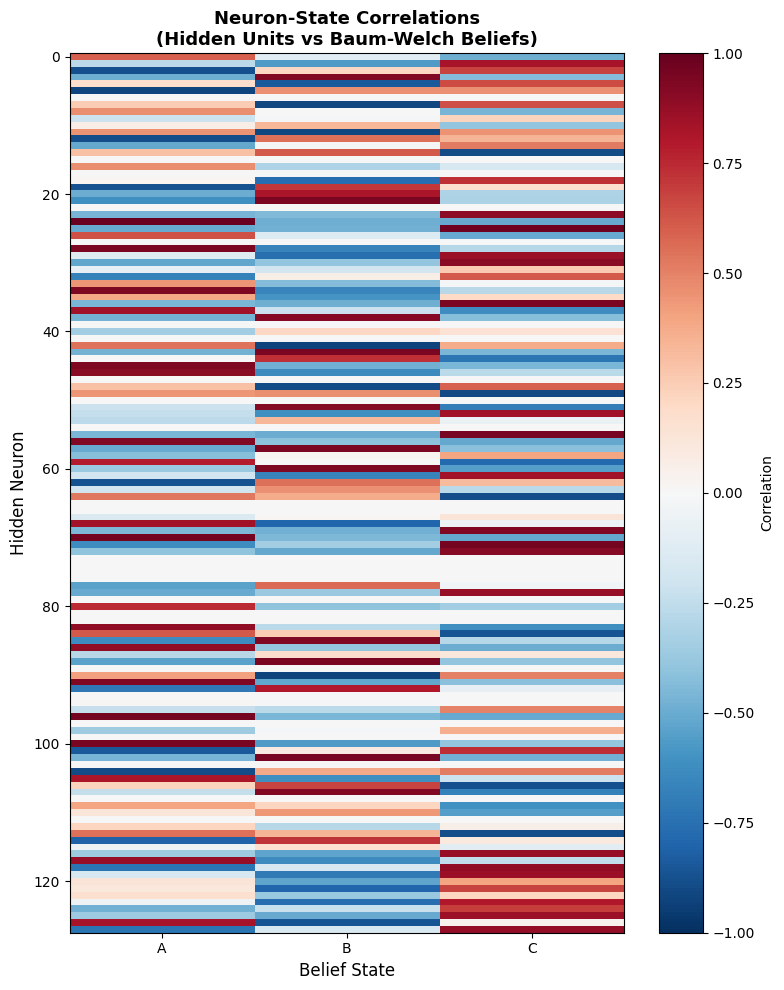

In [31]:
def analyze_state_inference(model, hmm, test_data, device, n_sequences=100):
    """Analyze how well model's hidden states correlate with Baum-Welch beliefs."""

    print("Analyzing state inference quality:")
    print("=" * 60)

    # Collect hidden states and belief states across all timesteps
    all_hidden = []
    all_beliefs = []

    model.eval()
    with torch.no_grad():
        for i in range(min(n_sequences, len(test_data['observations']))):
            obs_onehot = torch.FloatTensor(test_data['obs_onehot'][i:i+1]).to(device)

            # Get hidden states at ALL timesteps (not just final)
            batch_size, seq_len, _ = obs_onehot.shape
            h = torch.zeros(1, batch_size, model.hidden_size).to(device)

            hidden_sequence = []
            for t in range(seq_len):
                x_t = obs_onehot[:, t:t+1, :]
                out, h = model.rnn(x_t, h)
                h_clamped = torch.where(h > 0, h, torch.zeros_like(h))
                h = h_clamped
                hidden_sequence.append(h.squeeze(0).cpu().numpy())  # (batch=1, hidden_size)

            hidden_sequence = np.array(hidden_sequence).squeeze(1)  # (seq_length, hidden_size)

            # Compute belief states
            beliefs = hmm.forward_inference(test_data['observations'][i])  # (seq_length, 3)

            all_hidden.append(hidden_sequence)
            all_beliefs.append(beliefs)

    # Flatten across sequences
    hidden_matrix = np.concatenate(all_hidden, axis=0)  # (n_samples, hidden_size)
    beliefs_matrix = np.concatenate(all_beliefs, axis=0)  # (n_samples, 3)

    print(f"\nAnalyzing {hidden_matrix.shape[0]} timesteps from {n_sequences} sequences")
    print(f"Hidden states shape: {hidden_matrix.shape}")
    print(f"Belief states shape: {beliefs_matrix.shape}")

    # Compute correlations
    correlations = np.zeros((model.hidden_size, 3))
    for h in range(model.hidden_size):
        for s in range(3):
            correlations[h, s] = np.corrcoef(hidden_matrix[:, h], beliefs_matrix[:, s])[0, 1]

    # Handle NaN correlations (constant neurons)
    correlations = np.nan_to_num(correlations, 0)

    # Find neurons most correlated with each state
    top_k = tk
    state_names = ['A', 'B', 'C']

    print("\nTop neurons for each state (by correlation with Baum-Welch):")
    for s in range(3):
        top_neurons = np.argsort(-np.abs(correlations[:, s]))[:top_k]
        print(f"\nState {state_names[s]}:")
        for rank, neuron_idx in enumerate(top_neurons[:5]):  # Show top 5
            corr = correlations[neuron_idx, s]
            print(f"  {rank+1}. Neuron {neuron_idx:3d}: r = {corr:+.3f}")

    # Overall statistics
    max_corr_per_neuron = np.abs(correlations).max(axis=1)

    print("\n" + "=" * 60)
    print("Overall selectivity statistics:")
    print(f"  Mean max |correlation|: {max_corr_per_neuron.mean():.3f}")
    print(f"  Median max |correlation|: {np.median(max_corr_per_neuron):.3f}")
    print(f"  Neurons with |r| > 0.5: {(max_corr_per_neuron > 0.5).sum()} / {model.hidden_size}")
    print(f"  Neurons with |r| > 0.3: {(max_corr_per_neuron > 0.3).sum()} / {model.hidden_size}")

    if max_corr_per_neuron.mean() < 0.2:
        print("\n⚠️  Very weak state encoding - model may not be learning state representations")
    elif max_corr_per_neuron.mean() < 0.4:
        print("\n⚠️  Moderate state encoding - model is learning but could be clearer")
    else:
        print("\n✓  Strong state encoding - model has clear state-selective neurons")

    # Visualize correlation matrix
    fig, ax = plt.subplots(figsize=(8, 10))
    im = ax.imshow(correlations, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xlabel('Belief State', fontsize=12)
    ax.set_ylabel('Hidden Neuron', fontsize=12)
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['A', 'B', 'C'])
    ax.set_title('Neuron-State Correlations\n(Hidden Units vs Baum-Welch Beliefs)',
                fontsize=13, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Correlation')
    plt.tight_layout()
    plt.show()

    return correlations

correlations = analyze_state_inference(model, hmm, test_data, device, n_sequences=200)

### Circuit Discovery!

#### Generate diagnostic sequences

Generating diagnostic sequences for circuit analysis...
✓ Created maintain_A: (64, 20, 3)
✓ Created maintain_B: (64, 20, 3)
✓ Created maintain_C: (64, 20, 3)
✓ Created transition_A_to_B: (64, 20, 3)
✓ Created transition_B_to_C: (64, 20, 3)
✓ Created transition_C_to_A: (64, 20, 3)

Total diagnostic patterns: 6

Example patterns:


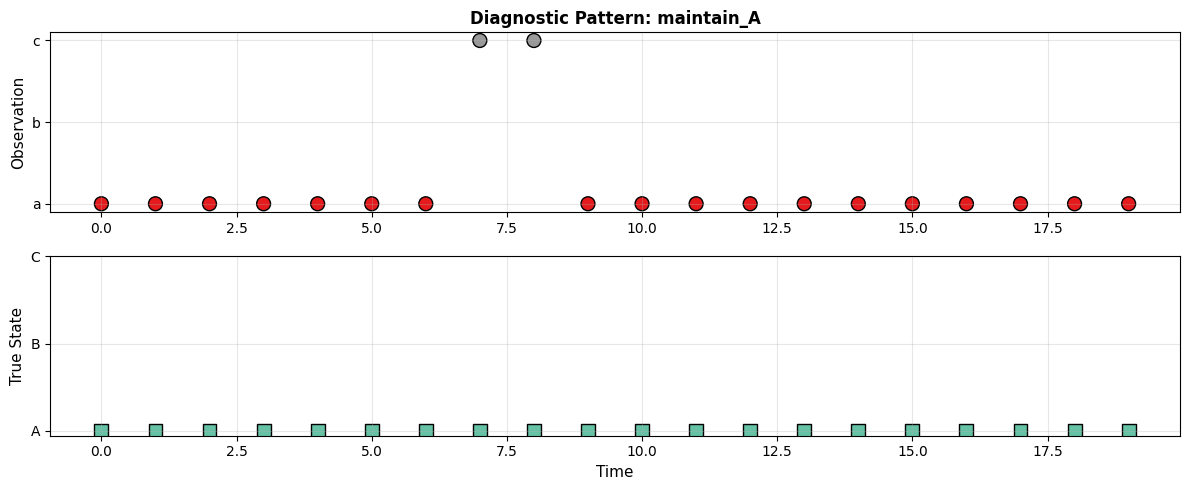

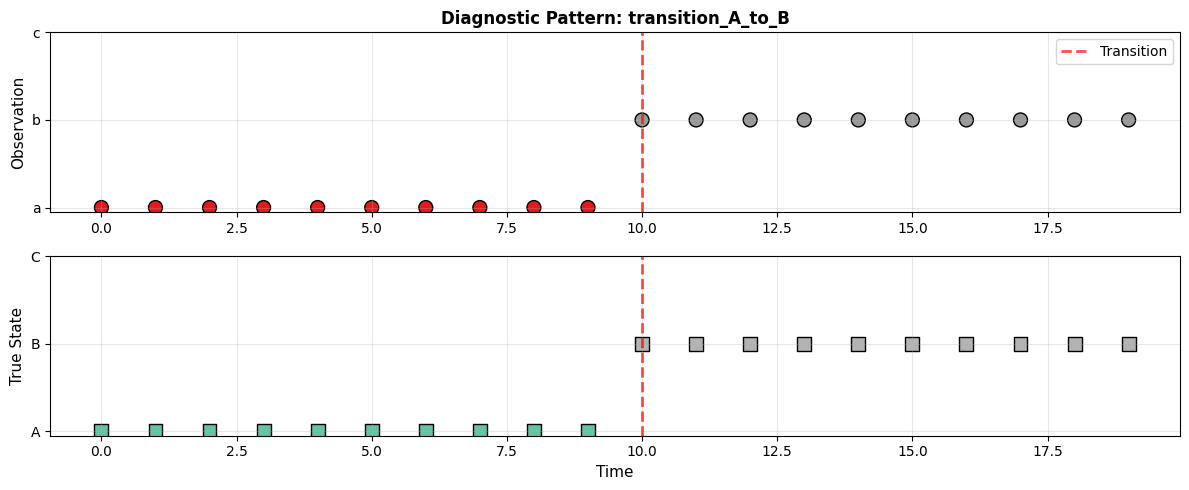

In [32]:
# Generate diagnostic patterns for circuit analysis
diagnostic_patterns = {}

print("Generating diagnostic sequences for circuit analysis...")
print("=" * 60)

# Maintenance patterns (stay in one state)
for state, state_name in [(0, 'A'), (1, 'B'), (2, 'C')]:
    pattern = hmm.generate_diagnostic_sequences(
        n_sequences=64,
        seq_length=20,
        pattern_type=f'maintain_{state_name}'
    )
    diagnostic_patterns[f'maintain_{state_name}'] = pattern
    print(f"✓ Created maintain_{state_name}: {pattern['obs_onehot'].shape}")

# Transition patterns (switch states at midpoint)
transitions = [('A', 'B'), ('B', 'C'), ('C', 'A')]
for from_state, to_state in transitions:
    pattern = hmm.generate_diagnostic_sequences(
        n_sequences=64,
        seq_length=20,
        pattern_type=f'transition_{from_state}_to_{to_state}'
    )
    diagnostic_patterns[f'transition_{from_state}_to_{to_state}'] = pattern
    print(f"✓ Created transition_{from_state}_to_{to_state}: {pattern['obs_onehot'].shape}")

print(f"\nTotal diagnostic patterns: {len(diagnostic_patterns)}")

# Visualize example diagnostic patterns
def plot_diagnostic_pattern(pattern_dict, pattern_name):
    """Visualize a diagnostic pattern."""
    obs = pattern_dict['observations'][0]  # First sequence
    states = pattern_dict['states'][0]

    fig, axes = plt.subplots(2, 1, figsize=(12, 5))
    times = range(len(obs))

    # Observations
    ax = axes[0]
    ax.scatter(times, obs, c=obs, cmap='Set1', s=100, edgecolors='black')
    ax.set_ylabel('Observation', fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['a', 'b', 'c'])
    ax.set_title(f'Diagnostic Pattern: {pattern_name}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

    # States
    ax = axes[1]
    ax.scatter(times, states, c=states, cmap='Set2', s=100, edgecolors='black', marker='s')
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylabel('True State', fontsize=11)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['A', 'B', 'C'])
    ax.grid(alpha=0.3)

    # Mark transition point for transition patterns
    if 'transition' in pattern_name:
        mid = len(obs) // 2
        for ax in axes:
            ax.axvline(mid, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Transition')
        axes[0].legend()

    plt.tight_layout()
    plt.show()

# Show examples
print("\nExample patterns:")
plot_diagnostic_pattern(diagnostic_patterns['maintain_A'], 'maintain_A')
plot_diagnostic_pattern(diagnostic_patterns['transition_A_to_B'], 'transition_A_to_B')

#### HMM circuit analyzer

In [33]:
class HMMCircuitAnalyzer:
    """Circuit discovery for HMM state inference task using activation patching.

    Adapted from FlipFlopCircuitAnalyzer for next-observation prediction task.
    """

    def __init__(self, model, hmm, device):
        """
        Args:
            model: Trained RNN model
            hmm: HMM object (for computing belief states)
            device: torch device
        """
        self.model = model
        self.hmm = hmm
        self.device = device
        self.hidden_size = model.hidden_size

    def run_and_record(self, inputs):
        """Run model and record hidden states + predictions.

        Args:
            inputs: (batch, seq_length, 3) one-hot observations

        Returns:
            dict with 'hidden', 'logits', 'predicted_obs', 'inputs'
        """
        self.model.eval()

        if isinstance(inputs, np.ndarray):
            inputs = torch.FloatTensor(inputs)
        inputs = inputs.to(self.device)

        B, T, _ = inputs.shape
        hidden_states = []
        logits_seq = []

        h = torch.zeros(1, B, self.hidden_size, device=self.device)

        with torch.no_grad():
            for t in range(T):
                x_t = inputs[:, t:t+1, :]
                out, h = self.model.rnn(x_t, h)
                h = torch.where(h > 0, h, torch.zeros_like(h))

                hidden_states.append(h.squeeze(0).detach().cpu())

                # Get logits for next observation
                z_t = self.model.fc(h.squeeze(0))
                logits_seq.append(z_t.detach().cpu())

        hidden_states = torch.stack(hidden_states, dim=1)  # (B, T, H)
        logits = torch.stack(logits_seq, dim=1)  # (B, T, 3)
        predicted_obs = torch.argmax(logits, dim=-1)  # (B, T)

        return {
            'hidden': hidden_states,
            'logits': logits,
            'predicted_obs': predicted_obs,
            'inputs': inputs.cpu()
        }

    def _prediction_margin(self, logits, ref_obs=None):
        """Compute per-(B,T) margin = logit[target] - max(logit[others]).

        Args:
            logits: (B, T, 3) prediction logits
            ref_obs: (B, T) reference observations (if None, uses argmax)
        """
        if ref_obs is None:
            ref = torch.argmax(logits, dim=-1)  # (B, T)
        else:
            ref = ref_obs

        ref_logit = logits.gather(-1, ref.unsqueeze(-1)).squeeze(-1)  # (B, T)

        # Max of non-target logits
        mask = torch.zeros_like(logits, dtype=torch.bool)
        mask.scatter_(-1, ref.unsqueeze(-1), True)
        other_max = logits.masked_fill(mask, -1e9).max(dim=-1).values

        return ref_logit - other_max  # (B, T)

    def _window_mean(self, x, window):
        """Mean over window [start, end)."""
        s, e = window
        if e <= s:
            return torch.tensor(0.0)
        return x[:, s:e].mean()

    def _apply_soft_ablation(self, hidden, neuron_idx, window, alpha=0.05):
        """Scale neuron by alpha within window."""
        s, e = window
        hidden_copy = hidden.clone()
        hidden_copy[:, s:e, neuron_idx] = hidden_copy[:, s:e, neuron_idx] * alpha
        return hidden_copy

    def rollout_with_patch(self, target_run, patched_hidden, time_window=None):
        """Causally re-simulate from patched hidden states."""
        self.model.eval()
        inputs = target_run['inputs'].to(self.device)
        B, T, _ = inputs.shape
        start, end = (0, T) if time_window is None else time_window

        h = torch.zeros(1, B, self.hidden_size, device=self.device)
        logits_seq = []

        with torch.no_grad():
            for t in range(T):
                x_t = inputs[:, t:t+1, :]
                out, h = self.model.rnn(x_t, h)
                h = torch.where(h > 0, h, torch.zeros_like(h))

                # Apply patch inside window
                if start <= t < end:
                    h = patched_hidden[:, t, :].unsqueeze(0).to(self.device)
                    h = torch.where(h > 0, h, torch.zeros_like(h))

                z_t = self.model.fc(h.squeeze(0))
                logits_seq.append(z_t.detach().cpu())

        logits = torch.stack(logits_seq, dim=1)
        predicted_obs = torch.argmax(logits, dim=-1)

        return {'logits': logits, 'predicted_obs': predicted_obs, 'inputs': target_run['inputs']}

    def find_state_maintenance_circuit(self, state_name='A', verbose=True):
        """Find neurons critical for maintaining a specific state.

        Uses soft ablation (necessity) on maintain_X patterns.
        """
        pattern = diagnostic_patterns[f'maintain_{state_name}']
        base_run = self.run_and_record(pattern['obs_onehot'])

        # Define window (middle portion where state is stable)
        window = (5, 15)

        # Compute baseline margin
        base_margin = self._prediction_margin(base_run['logits'])

        # Test each neuron
        importance = torch.zeros(self.hidden_size)

        for neuron_idx in range(self.hidden_size):
            patched_hidden = self._apply_soft_ablation(base_run['hidden'], neuron_idx, window, alpha=0.05)
            patched_run = self.rollout_with_patch(base_run, patched_hidden, time_window=window)
            patched_margin = self._prediction_margin(patched_run['logits'])

            # Importance = drop in margin when ablated
            importance[neuron_idx] = self._window_mean(base_margin - patched_margin, window).item()

        # Get top neurons
        top_k = tk
        scores, neurons = torch.topk(importance, k=min(top_k, self.hidden_size))

        if verbose:
            print(f"\n=== State {state_name} Maintenance Circuit ===")
            print(f"Top {top_k} neurons: {neurons.tolist()}")
            print(f"Importance scores: {scores.tolist()}")

        return {
            'importance': importance,
            'top_neurons': neurons,
            'scores': scores,
            'state': state_name
        }

    def find_state_transition_circuit(self, from_state='A', to_state='B', verbose=True):
        """Find neurons critical for state transitions.

        Uses soft ablation around the transition point.
        """
        pattern = diagnostic_patterns[f'transition_{from_state}_to_{to_state}']
        base_run = self.run_and_record(pattern['obs_onehot'])

        # Window around transition point (middle of sequence)
        mid = pattern['obs_onehot'].shape[1] // 2
        window = (mid - 2, mid + 3)

        base_margin = self._prediction_margin(base_run['logits'])
        importance = torch.zeros(self.hidden_size)

        for neuron_idx in range(self.hidden_size):
            patched_hidden = self._apply_soft_ablation(base_run['hidden'], neuron_idx, window, alpha=0.05)
            patched_run = self.rollout_with_patch(base_run, patched_hidden, time_window=window)
            patched_margin = self._prediction_margin(patched_run['logits'])

            importance[neuron_idx] = self._window_mean(base_margin - patched_margin, window).item()

        top_k = tk
        scores, neurons = torch.topk(importance, k=min(top_k, self.hidden_size))

        if verbose:
            print(f"\n=== Transition {from_state}→{to_state} Circuit ===")
            print(f"Top {top_k} neurons: {neurons.tolist()}")
            print(f"Importance scores: {scores.tolist()}")

        return {
            'importance': importance,
            'top_neurons': neurons,
            'scores': scores,
            'transition': f"{from_state}_to_{to_state}"
        }

# Initialize analyzer
analyzer = HMMCircuitAnalyzer(model, hmm, device)
print("✓ HMMCircuitAnalyzer initialized")

✓ HMMCircuitAnalyzer initialized


#### Run circuit discovery

In [34]:
print("Running circuit discovery...")
print("=" * 60)

# Discover maintenance circuits for each state
maintenance_circuits = {}
for state_name in ['A', 'B', 'C']:
    circuit = analyzer.find_state_maintenance_circuit(state_name, verbose=True)
    maintenance_circuits[state_name] = circuit

# Discover transition circuits
transition_circuits = {}
for from_state, to_state in [('A', 'B'), ('B', 'C'), ('C', 'A')]:
    circuit = analyzer.find_state_transition_circuit(from_state, to_state, verbose=True)
    transition_circuits[f"{from_state}_to_{to_state}"] = circuit

print("\n" + "=" * 60)
print("Circuit discovery complete!")

Running circuit discovery...

=== State A Maintenance Circuit ===
Top 5 neurons: [105, 86, 90, 45, 8]
Importance scores: [0.186311274766922, 0.1826489269733429, 0.16536977887153625, 0.14808952808380127, 0.14426176249980927]

=== State B Maintenance Circuit ===
Top 5 neurons: [64, 88, 3, 77, 63]
Importance scores: [0.1335429698228836, 0.13031964004039764, 0.1272021234035492, 0.12572649121284485, 0.12518607079982758]

=== State C Maintenance Circuit ===
Top 5 neurons: [30, 2, 124, 5, 118]
Importance scores: [0.21001414954662323, 0.1908617913722992, 0.14918586611747742, 0.14908452332019806, 0.13945068418979645]

=== Transition A→B Circuit ===
Top 5 neurons: [64, 84, 53, 88, 113]
Importance scores: [0.06621894985437393, 0.05736984685063362, 0.055991798639297485, 0.055299997329711914, 0.0501788966357708]

=== Transition B→C Circuit ===
Top 5 neurons: [30, 2, 118, 72, 71]
Importance scores: [0.09070292860269547, 0.07798559963703156, 0.06392993032932281, 0.06301500648260117, 0.058798320591449

#### Validate against Baum-Welch

In [35]:
# def validate_circuit_discovery(discovered_circuits, ground_truth_correlations,
#                                state_idx, state_name, top_k=3):
#     """Compare discovered circuit to Baum-Welch ground truth.

#     Args:
#         discovered_circuits: Circuit dict from analyzer
#         ground_truth_correlations: (hidden_size, 3) correlation matrix
#         state_idx: 0, 1, or 2 (A, B, C)
#         state_name: 'A', 'B', or 'C'
#         top_k: Number of top neurons to consider
#     """
#     # Get discovered neurons
#     discovered = discovered_circuits[state_name]['top_neurons'][:top_k].numpy()

#     # Get ground truth neurons (by Baum-Welch correlation)
#     state_corr = ground_truth_correlations[:, state_idx]
#     gt_top_indices = np.argsort(-np.abs(state_corr))[:top_k]

#     # Compute overlap metrics
#     discovered_set = set(discovered)
#     gt_set = set(gt_top_indices)

#     overlap = discovered_set.intersection(gt_set)

#     precision = len(overlap) / len(discovered_set) if len(discovered_set) > 0 else 0
#     recall = len(overlap) / len(gt_set) if len(gt_set) > 0 else 0
#     f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

#     jaccard = len(overlap) / len(discovered_set.union(gt_set))

#     return {
#         'discovered': discovered,
#         'ground_truth': gt_top_indices,
#         'overlap': list(overlap),
#         'precision': precision,
#         'recall': recall,
#         'f1': f1,
#         'jaccard': jaccard,
#         'state': state_name
#     }

# print("Validating circuit discovery against Baum-Welch ground truth...")
# print("=" * 60)

# validation_results = {}

# # Validate maintenance circuits
# print("\n=== Maintenance Circuit Validation ===\n")
# for state_idx, state_name in enumerate(['A', 'B', 'C']):
#     result = validate_circuit_discovery(
#         maintenance_circuits,
#         correlations,
#         state_idx,
#         state_name,
#         top_k=3
#     )
#     validation_results[f'maintain_{state_name}'] = result

#     print(f"State {state_name} Maintenance:")
#     print(f"  Discovered neurons: {result['discovered']}")
#     print(f"  Ground truth neurons: {result['ground_truth']}")
#     print(f"  Overlap: {result['overlap']}")
#     print(f"  Precision: {result['precision']:.2%}")
#     print(f"  Recall: {result['recall']:.2%}")
#     print(f"  F1 Score: {result['f1']:.2%}")
#     print(f"  Jaccard Index: {result['jaccard']:.2%}")
#     print()

# # Compute average metrics
# avg_precision = np.mean([v['precision'] for k, v in validation_results.items() if 'maintain' in k])
# avg_recall = np.mean([v['recall'] for k, v in validation_results.items() if 'maintain' in k])
# avg_f1 = np.mean([v['f1'] for k, v in validation_results.items() if 'maintain' in k])
# avg_jaccard = np.mean([v['jaccard'] for k, v in validation_results.items() if 'maintain' in k])

# print("=" * 60)
# print("Average Validation Metrics (Maintenance Circuits):")
# print(f"  Precision: {avg_precision:.2%}")
# print(f"  Recall: {avg_recall:.2%}")
# print(f"  F1 Score: {avg_f1:.2%}")
# print(f"  Jaccard Index: {avg_jaccard:.2%}")

# # Interpret results
# if avg_precision > 0.7 and avg_recall > 0.7:
#     print("\n✓ Excellent validation! Circuit discovery successfully recovers ground truth.")
# elif avg_precision > 0.5 and avg_recall > 0.5:
#     print("\n⚠ Good validation. Circuit discovery captures meaningful structure.")
# elif avg_precision > 0.3 or avg_recall > 0.3:
#     print("\n⚠ Moderate validation. Some overlap but room for improvement.")
# else:
#     print("\n✗ Poor validation. Circuit discovery not matching ground truth.")

# # Visualize validation
# fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# for state_idx, (ax, state_name) in enumerate(zip(axes, ['A', 'B', 'C'])):
#     result = validation_results[f'maintain_{state_name}']

#     # Create Venn-like visualization
#     all_neurons = sorted(set(result['discovered']) | set(result['ground_truth']))
#     n_neurons = len(all_neurons)

#     neuron_to_idx = {n: i for i, n in enumerate(all_neurons)}

#     discovered_mask = np.array([1 if n in result['discovered'] else 0 for n in all_neurons])
#     gt_mask = np.array([1 if n in result['ground_truth'] else 0 for n in all_neurons])
#     overlap_mask = discovered_mask * gt_mask

#     # Plot as stacked bars
#     x = np.arange(n_neurons)
#     width = 0.8

#     # Color code: overlap=purple, discovered only=orange, GT only=blue
#     colors = []
#     for i in range(n_neurons):
#         if overlap_mask[i]:
#             colors.append('#9467bd')  # Purple (overlap)
#         elif discovered_mask[i]:
#             colors.append('#ff7f0e')  # Orange (discovered only)
#         else:
#             colors.append('#1f77b4')  # Blue (GT only)

#     ax.bar(x, np.ones(n_neurons), color=colors, width=width)
#     ax.set_xlabel('Neuron Index (sorted)', fontsize=11)
#     ax.set_ylabel('Membership', fontsize=11)
#     ax.set_title(f'State {state_name}\nP={result["precision"]:.2f}, R={result["recall"]:.2f}',
#                 fontsize=12, fontweight='bold')
#     ax.set_ylim([0, 1.2])
#     ax.set_yticks([])

#     # Add legend
#     from matplotlib.patches import Patch
#     legend_elements = [
#         Patch(facecolor='#9467bd', label='Both (overlap)'),
#         Patch(facecolor='#ff7f0e', label='Discovered only'),
#         Patch(facecolor='#1f77b4', label='Ground truth only')
#     ]
#     ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, 'circuit_validation.png'), dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\nValidation figure saved to: {os.path.join(save_dir, 'circuit_validation.png')}")

#### Validate w.r.t. decoding performance (Functional validation)

In [36]:
def train_state_decoder(hidden_states, true_states, neuron_indices=None):
    """Train linear decoder to predict state from hidden activity.

    Args:
        hidden_states: (n_samples, hidden_size) array
        true_states: (n_samples,) array of states {0, 1, 2}
        neuron_indices: If provided, only use these neurons

    Returns:
        Trained decoder and accuracy
    """
    # Select neurons
    if neuron_indices is not None:
        X = hidden_states[:, neuron_indices]
    else:
        X = hidden_states

    # Train decoder
    decoder = LogisticRegression(max_iter=1000, random_state=42)
    decoder.fit(X, true_states)

    # Evaluate
    pred = decoder.predict(X)
    acc = accuracy_score(true_states, pred)

    return decoder, acc, pred

In [37]:
def collect_hidden_states_with_beliefs(model, hmm, test_data, device, n_sequences=200):
    """Collect hidden states and compute Baum-Welch labels."""
    all_hidden = []
    all_belief_labels = []  # Argmax of Baum-Welch beliefs

    model.eval()
    with torch.no_grad():
        for i in range(min(n_sequences, len(test_data['observations']))):
            obs_onehot = torch.FloatTensor(test_data['obs_onehot'][i:i+1]).to(device)

            # Get hidden states at all timesteps
            batch_size, seq_len, _ = obs_onehot.shape
            h = torch.zeros(1, batch_size, model.hidden_size).to(device)

            hidden_sequence = []
            for t in range(seq_len):
                x_t = obs_onehot[:, t:t+1, :]
                out, h = model.rnn(x_t, h)
                h_clamped = torch.where(h > 0, h, torch.zeros_like(h))
                h = h_clamped
                hidden_sequence.append(h.squeeze(0).cpu().numpy())

            hidden_sequence = np.array(hidden_sequence).squeeze(1)  # (seq_length, hidden_size)

            # Compute belief states and take argmax as label
            beliefs = hmm.forward_inference(test_data['observations'][i])  # (seq_length, 3)
            belief_labels = np.argmax(beliefs, axis=1)  # (seq_length,)

            all_hidden.append(hidden_sequence)
            all_belief_labels.append(belief_labels)

    hidden_matrix = np.concatenate(all_hidden, axis=0)  # (n_samples, hidden_size)
    label_vector = np.concatenate(all_belief_labels, axis=0)  # (n_samples,)

    return hidden_matrix, label_vector

In [38]:
print("Functional Validation: Decoder Performance")
print("=" * 60)

# Collect data
print("\nCollecting hidden states and belief labels...")
hidden_matrix, belief_labels = collect_hidden_states_with_beliefs(
    model, hmm, test_data, device, n_sequences=200
)
print(f"Collected {hidden_matrix.shape[0]} samples from 200 sequences")
print(f"Hidden states: {hidden_matrix.shape}")
print(f"Labels: {belief_labels.shape}")

# Define neuron sets to compare
neuron_sets = {}

# 1. All neurons (baseline)
neuron_sets['all_neurons'] = np.arange(model.hidden_size)

# 2. Discovered neurons (from circuit discovery)
for state_name in ['A', 'B', 'C']:
    discovered = maintenance_circuits[state_name]['top_neurons'].numpy()
    neuron_sets[f'discovered_{state_name}'] = discovered

# 3. Ground truth (Baum-Welch correlation)
for state_idx, state_name in enumerate(['A', 'B', 'C']):
    state_corr = correlations[:, state_idx]
    bw_top = np.argsort(-np.abs(state_corr))[:tk]
    neuron_sets[f'baum_welch_{state_name}'] = bw_top

# 4. Random neurons (control)
np.random.seed(42)
for state_name in ['A', 'B', 'C']:
    random_neurons = np.random.choice(model.hidden_size, size=tk, replace=False)
    neuron_sets[f'random_{state_name}'] = random_neurons

# 5. Combined discovered neurons (all maintenance circuits)
all_discovered = np.unique(np.concatenate([
    maintenance_circuits['A']['top_neurons'].numpy(),
    maintenance_circuits['B']['top_neurons'].numpy(),
    maintenance_circuits['C']['top_neurons'].numpy()
]))
neuron_sets['all_discovered'] = all_discovered

# 6. Combined Baum-Welch neurons
all_bw = np.unique(np.concatenate([
    neuron_sets['baum_welch_A'],
    neuron_sets['baum_welch_B'],
    neuron_sets['baum_welch_C']
]))
neuron_sets['all_baum_welch'] = all_bw

Functional Validation: Decoder Performance

Collected 4000 samples from 200 sequences
Hidden states: (4000, 128)
Labels: (4000,)


In [39]:
print("\n" + "=" * 60)
print("Training decoders and comparing performance...")
print("=" * 60)

results = {}

# Train decoders
for name, neurons in neuron_sets.items():
    decoder, acc, pred = train_state_decoder(hidden_matrix, belief_labels, neurons)
    results[name] = {
        'neurons': neurons,
        'n_neurons': len(neurons),
        'accuracy': acc,
        'decoder': decoder,
        'predictions': pred
    }

# Display results
print("\n=== Decoder Performance Comparison ===\n")

# Baseline
baseline_acc = results['all_neurons']['accuracy']
print(f"Baseline (all {model.hidden_size} neurons): {baseline_acc:.2%}")
print()

# Per-state discovered vs Baum-Welch vs random
print("Per-State Comparison (k neurons each):")
print("-" * 60)
for state_name in ['A', 'B', 'C']:
    disc_acc = results[f'discovered_{state_name}']['accuracy']
    bw_acc = results[f'baum_welch_{state_name}']['accuracy']
    rand_acc = results[f'random_{state_name}']['accuracy']

    print(f"\nState {state_name}:")
    print(f"  Discovered neurons:  {disc_acc:.2%} (Δ from baseline: {disc_acc - baseline_acc:+.2%})")
    print(f"  Baum-Welch neurons:  {bw_acc:.2%} (Δ from baseline: {bw_acc - baseline_acc:+.2%})")
    print(f"  Random neurons:      {rand_acc:.2%} (Δ from baseline: {rand_acc - baseline_acc:+.2%})")

    # Highlight best
    best = max(disc_acc, bw_acc, rand_acc)
    if disc_acc == best:
        print(f"  → Discovered neurons are best!")
    elif bw_acc == best:
        print(f"  → Baum-Welch neurons are best")
    else:
        print(f"  → Random neurons are best (unexpected!)")


Training decoders and comparing performance...

=== Decoder Performance Comparison ===

Baseline (all 128 neurons): 100.00%

Per-State Comparison (k neurons each):
------------------------------------------------------------

State A:
  Discovered neurons:  98.98% (Δ from baseline: -1.02%)
  Baum-Welch neurons:  94.67% (Δ from baseline: -5.33%)
  Random neurons:      97.47% (Δ from baseline: -2.52%)
  → Discovered neurons are best!

State B:
  Discovered neurons:  95.88% (Δ from baseline: -4.13%)
  Baum-Welch neurons:  84.35% (Δ from baseline: -15.65%)
  Random neurons:      88.42% (Δ from baseline: -11.58%)
  → Discovered neurons are best!

State C:
  Discovered neurons:  95.93% (Δ from baseline: -4.07%)
  Baum-Welch neurons:  91.77% (Δ from baseline: -8.23%)
  Random neurons:      96.17% (Δ from baseline: -3.83%)
  → Random neurons are best (unexpected!)


In [40]:
# Combined comparison
print("\n" + "=" * 60)
print("Combined Circuit Performance:")
print("-" * 60)

comb_disc_acc = results['all_discovered']['accuracy']
comb_bw_acc = results['all_baum_welch']['accuracy']
n_disc = results['all_discovered']['n_neurons']
n_bw = results['all_baum_welch']['n_neurons']

print(f"\nAll discovered neurons ({n_disc} total):  {comb_disc_acc:.2%}")
print(f"All Baum-Welch neurons ({n_bw} total):    {comb_bw_acc:.2%}")
print(f"Baseline (all {model.hidden_size} neurons):          {baseline_acc:.2%}")

# Compute efficiency metric (accuracy per neuron)
disc_efficiency = comb_disc_acc / n_disc
bw_efficiency = comb_bw_acc / n_bw
baseline_efficiency = baseline_acc / model.hidden_size

print(f"\nEfficiency (accuracy per neuron):")
print(f"  Discovered: {disc_efficiency:.4f}")
print(f"  Baum-Welch: {bw_efficiency:.4f}")
print(f"  Baseline:   {baseline_efficiency:.4f}")


Combined Circuit Performance:
------------------------------------------------------------

All discovered neurons (15 total):  100.00%
All Baum-Welch neurons (15 total):    100.00%
Baseline (all 128 neurons):          100.00%

Efficiency (accuracy per neuron):
  Discovered: 0.0667
  Baum-Welch: 0.0667
  Baseline:   0.0078


In [41]:
# Interpretation
print("\n" + "=" * 60)
print("Interpretation:")

# Check if discovered neurons are sufficient
if comb_disc_acc > baseline_acc * 0.95:
    print(f"✓ Discovered neurons ({n_disc}) achieve {comb_disc_acc:.1%} of baseline performance")
    print("  → Circuit discovery successfully identifies functionally sufficient neurons")
elif comb_disc_acc > baseline_acc * 0.85:
    print(f"⚠ Discovered neurons achieve {comb_disc_acc:.1%} (moderate performance)")
    print("  → Some task-relevant structure captured")
else:
    print(f"✗ Discovered neurons achieve only {comb_disc_acc:.1%} (poor performance)")
    print("  → Circuit discovery may not capture critical neurons")

# Compare to Baum-Welch
if comb_disc_acc > comb_bw_acc:
    print(f"\n✓ Discovered neurons outperform Baum-Welch correlation ({comb_disc_acc:.1%} vs {comb_bw_acc:.1%})")
    print("  → Causal interventions identify more task-relevant neurons than correlation")
elif abs(comb_disc_acc - comb_bw_acc) < 0.02:
    print(f"\n≈ Discovered and Baum-Welch neurons perform similarly ({comb_disc_acc:.1%} vs {comb_bw_acc:.1%})")
    print("  → Both methods capture comparable functional structure")
else:
    print(f"\n⚠ Baum-Welch neurons outperform discovered ({comb_bw_acc:.1%} vs {comb_disc_acc:.1%})")
    print("  → Correlation-based selection may be more effective for this task")


Interpretation:
✓ Discovered neurons (15) achieve 100.0% of baseline performance
  → Circuit discovery successfully identifies functionally sufficient neurons

≈ Discovered and Baum-Welch neurons perform similarly (100.0% vs 100.0%)
  → Both methods capture comparable functional structure


In [42]:
# # Visualize comparison
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Left: Per-state comparison
# ax = axes[0]
# states = ['A', 'B', 'C']
# x = np.arange(len(states))
# width = 0.25

# disc_accs = [results[f'discovered_{s}']['accuracy'] for s in states]
# bw_accs = [results[f'baum_welch_{s}']['accuracy'] for s in states]
# rand_accs = [results[f'random_{s}']['accuracy'] for s in states]

# ax.bar(x - width, disc_accs, width, label='Discovered', color='#ff7f0e')
# ax.bar(x, bw_accs, width, label='Baum-Welch', color='#2ca02c')
# ax.bar(x + width, rand_accs, width, label='Random', color='#d62728')
# ax.axhline(baseline_acc, color='black', linestyle='--', linewidth=2, label='Baseline (all neurons)')

# ax.set_xlabel('State', fontsize=12)
# ax.set_ylabel('Decoder Accuracy', fontsize=12)
# ax.set_title('Per-State Decoder Performance\n(k neurons each)', fontsize=13, fontweight='bold')
# ax.set_xticks(x)
# ax.set_xticklabels(states)
# ax.legend()
# ax.grid(alpha=0.3, axis='y')
# ax.set_ylim([0, 1])

# # Right: Combined comparison
# ax = axes[1]
# methods = ['Discovered\n(combined)', 'Baum-Welch\n(combined)', 'Baseline\n(all neurons)']
# accs = [comb_disc_acc, comb_bw_acc, baseline_acc]
# colors = ['#ff7f0e', '#2ca02c', '#1f77b4']

# bars = ax.bar(methods, accs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
# ax.set_ylabel('Decoder Accuracy', fontsize=12)
# ax.set_title('Combined Circuit Performance', fontsize=13, fontweight='bold')
# ax.set_ylim([0, 1])
# ax.grid(alpha=0.3, axis='y')

# # Add accuracy labels on bars
# for bar, acc in zip(bars, accs):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
#             f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# # Add neuron count labels
# for i, (bar, n) in enumerate(zip(bars, [n_disc, n_bw, model.hidden_size])):
#     ax.text(bar.get_x() + bar.get_width()/2., 0.05,
#             f'{n} neurons', ha='center', va='bottom', fontsize=9, style='italic')

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, 'decoder_validation.png'), dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\nValidation figure saved to: {os.path.join(save_dir, 'decoder_validation.png')}")

# # Save results
# validation_results = {
#     'decoder_accuracies': {k: v['accuracy'] for k, v in results.items()},
#     'neuron_counts': {k: v['n_neurons'] for k, v in results.items()},
#     'baseline_accuracy': baseline_acc,
#     'discovered_combined_accuracy': comb_disc_acc,
#     'baum_welch_combined_accuracy': comb_bw_acc,
# }

# with open(os.path.join(save_dir, 'decoder_validation.pkl'), 'wb') as f:
#     pickle.dump(validation_results, f)

# print(f"Results saved to: {os.path.join(save_dir, 'decoder_validation.pkl')}")

In [43]:
# print("\n" + "=" * 60)
# print("State-Specific Decoder Validation")
# print("=" * 60)
# print("\nDo discovered neurons for state X decode state X better than random?\n")

# # For each state, create binary classification task: "Is this state X?"
# state_specific_results = {}

# for state_idx, state_name in enumerate(['A', 'B', 'C']):
#     print(f"=== State {state_name} Binary Decoder ===")

#     # Create binary labels: 1 if state X, 0 otherwise
#     binary_labels = (belief_labels == state_idx).astype(int)

#     # Get neuron sets
#     discovered_neurons = maintenance_circuits[state_name]['top_neurons'][:3].numpy()

#     state_corr = correlations[:, state_idx]
#     bw_neurons = np.argsort(-np.abs(state_corr))[:3]

#     np.random.seed(42 + state_idx)  # Different seed per state
#     random_neurons = np.random.choice(model.hidden_size, size=3, replace=False)

#     # Train binary decoders
#     from sklearn.linear_model import LogisticRegression

#     results_state = {}
#     for method, neurons in [('Discovered', discovered_neurons),
#                             ('Baum-Welch', bw_neurons),
#                             ('Random', random_neurons),
#                             ('All', np.arange(model.hidden_size))]:
#         X = hidden_matrix[:, neurons]
#         clf = LogisticRegression(max_iter=1000, random_state=42)
#         clf.fit(X, binary_labels)
#         acc = clf.score(X, binary_labels)
#         results_state[method] = acc

#         if method != 'All':
#             print(f"  {method:15s} ({len(neurons):3d} neurons): {acc:.2%}")

#     print(f"  {'Baseline':15s} ({model.hidden_size:3d} neurons): {results_state['All']:.2%}")
#     print()

#     state_specific_results[state_name] = results_state

# # Summary comparison
# print("=" * 60)
# print("Summary: State-Specific Decoder Performance")
# print("=" * 60)

# import pandas as pd
# df = pd.DataFrame(state_specific_results).T
# print("\n", df.to_string())

# # Average performance
# avg_discovered = df['Discovered'].mean()
# avg_bw = df['Baum-Welch'].mean()
# avg_random = df['Random'].mean()

# print(f"\nAverage across states:")
# print(f"  Discovered: {avg_discovered:.2%}")
# print(f"  Baum-Welch: {avg_bw:.2%}")
# print(f"  Random:     {avg_random:.2%}")

# # Improvement over random
# print(f"\nImprovement over random:")
# print(f"  Discovered: +{(avg_discovered - avg_random)*100:.1f} percentage points")
# print(f"  Baum-Welch: +{(avg_bw - avg_random)*100:.1f} percentage points")

# # Visualize
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Left: Per-state binary classification
# ax = axes[0]
# states = ['A', 'B', 'C']
# x = np.arange(len(states))
# width = 0.25

# disc_accs = [state_specific_results[s]['Discovered'] for s in states]
# bw_accs = [state_specific_results[s]['Baum-Welch'] for s in states]
# rand_accs = [state_specific_results[s]['Random'] for s in states]

# ax.bar(x - width, disc_accs, width, label='Discovered', color='#ff7f0e')
# ax.bar(x, bw_accs, width, label='Baum-Welch', color='#2ca02c')
# ax.bar(x + width, rand_accs, width, label='Random', color='#d62728')

# ax.set_xlabel('State', fontsize=12)
# ax.set_ylabel('Binary Classification Accuracy\n(Is this state X?)', fontsize=12)
# ax.set_title('State-Specific Decoder Performance\n(k neurons each, binary task)',
#              fontsize=13, fontweight='bold')
# ax.set_xticks(x)
# ax.set_xticklabels(states)
# ax.legend()
# ax.grid(alpha=0.3, axis='y')
# ax.set_ylim([0.5, 1.0])

# # Right: Average comparison with error bars
# ax = axes[1]
# methods = ['Discovered', 'Baum-Welch', 'Random']
# avgs = [avg_discovered, avg_bw, avg_random]
# stds = [df['Discovered'].std(), df['Baum-Welch'].std(), df['Random'].std()]
# colors = ['#ff7f0e', '#2ca02c', '#d62728']

# bars = ax.bar(methods, avgs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
# ax.errorbar(methods, avgs, yerr=stds, fmt='none', color='black', capsize=5, linewidth=2)

# ax.set_ylabel('Average Binary Classification Accuracy', fontsize=12)
# ax.set_title('Average State-Specific Performance\n(across 3 states)',
#              fontsize=13, fontweight='bold')
# ax.set_ylim([0.5, 1.0])
# ax.grid(alpha=0.3, axis='y')

# # Add accuracy labels
# for bar, acc in zip(bars, avgs):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
#             f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, 'state_specific_validation.png'), dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\nFigure saved to: {os.path.join(save_dir, 'state_specific_validation.png')}")


State-Specific Decoder Validation (3-Way Classification)

Do neurons discovered for state X help decode all states in 3-way task?

=== State A Neurons (3-Way Task) ===
  Discovered      (  3 neurons): 87.65%
  Baum-Welch      (  3 neurons): 71.30%
  Random          (  3 neurons): 88.65%
  Baseline        (128 neurons): 100.00%

=== State B Neurons (3-Way Task) ===
  Discovered      (  3 neurons): 91.17%
  Baum-Welch      (  3 neurons): 82.83%
  Random          (  3 neurons): 91.72%
  Baseline        (128 neurons): 100.00%

=== State C Neurons (3-Way Task) ===
  Discovered      (  3 neurons): 91.20%
  Baum-Welch      (  3 neurons): 90.60%
  Random          (  3 neurons): 87.17%
  Baseline        (128 neurons): 100.00%

Summary: State-Specific Neurons on 3-Way Task

    Discovered  Baum-Welch   Random  All
A     0.87650     0.71300  0.88650  1.0
B     0.91175     0.82825  0.91725  1.0
C     0.91200     0.90600  0.87175  1.0

Average across states:
  Discovered: 90.01%
  Baum-Welch: 81.5

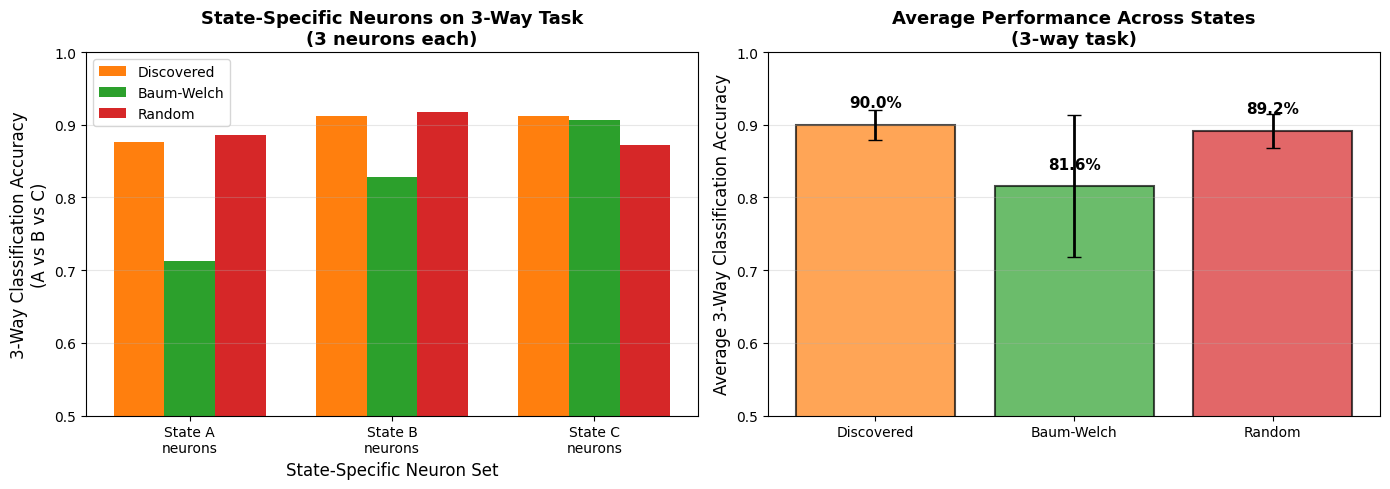


Figure saved to: /content/drive/MyDrive/dales-bp-mech-interp/hmm_gt/state_specific_validation_3way.png


In [44]:
print("\n" + "=" * 60)
print("State-Specific Decoder Validation (3-Way Classification)")
print("=" * 60)
print("\nDo neurons discovered for state X help decode all states in 3-way task?\n")

# For each state, use that state's neurons to decode the full 3-way task
state_specific_results = {}

for state_idx, state_name in enumerate(['A', 'B', 'C']):
    print(f"=== State {state_name} Neurons (3-Way Task) ===")

    # Get neuron sets
    discovered_neurons = maintenance_circuits[state_name]['top_neurons'][:3].numpy()

    state_corr = correlations[:, state_idx]
    bw_neurons = np.argsort(-np.abs(state_corr))[:3]

    np.random.seed(42 + state_idx)  # Different seed per state
    random_neurons = np.random.choice(model.hidden_size, size=3, replace=False)

    # Train 3-way decoders using belief_labels (not binary!)
    from sklearn.linear_model import LogisticRegression

    results_state = {}
    for method, neurons in [('Discovered', discovered_neurons),
                            ('Baum-Welch', bw_neurons),
                            ('Random', random_neurons),
                            ('All', np.arange(model.hidden_size))]:
        X = hidden_matrix[:, neurons]
        clf = LogisticRegression(max_iter=1000, random_state=42)
        clf.fit(X, belief_labels)  # 3-way labels {0, 1, 2}
        acc = clf.score(X, belief_labels)
        results_state[method] = acc

        if method != 'All':
            print(f"  {method:15s} ({len(neurons):3d} neurons): {acc:.2%}")

    print(f"  {'Baseline':15s} ({model.hidden_size:3d} neurons): {results_state['All']:.2%}")
    print()

    state_specific_results[state_name] = results_state

# Summary comparison
print("=" * 60)
print("Summary: State-Specific Neurons on 3-Way Task")
print("=" * 60)

import pandas as pd
df = pd.DataFrame(state_specific_results).T
print("\n", df.to_string())

# Average performance
avg_discovered = df['Discovered'].mean()
avg_bw = df['Baum-Welch'].mean()
avg_random = df['Random'].mean()

print(f"\nAverage across states:")
print(f"  Discovered: {avg_discovered:.2%}")
print(f"  Baum-Welch: {avg_bw:.2%}")
print(f"  Random:     {avg_random:.2%}")

# Improvement over random
print(f"\nImprovement over random:")
print(f"  Discovered: +{(avg_discovered - avg_random)*100:.1f} percentage points")
print(f"  Baum-Welch: +{(avg_bw - avg_random)*100:.1f} percentage points")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Per-state neurons on 3-way classification
ax = axes[0]
states = ['A', 'B', 'C']
x = np.arange(len(states))
width = 0.25

disc_accs = [state_specific_results[s]['Discovered'] for s in states]
bw_accs = [state_specific_results[s]['Baum-Welch'] for s in states]
rand_accs = [state_specific_results[s]['Random'] for s in states]

ax.bar(x - width, disc_accs, width, label='Discovered', color='#ff7f0e')
ax.bar(x, bw_accs, width, label='Baum-Welch', color='#2ca02c')
ax.bar(x + width, rand_accs, width, label='Random', color='#d62728')

ax.set_xlabel('State-Specific Neuron Set', fontsize=12)
ax.set_ylabel('3-Way Classification Accuracy\n(A vs B vs C)', fontsize=12)
ax.set_title('State-Specific Neurons on 3-Way Task\n(3 neurons each)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'State {s}\nneurons' for s in states])
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0.5, 1.0])

# Right: Average comparison with error bars
ax = axes[1]
methods = ['Discovered', 'Baum-Welch', 'Random']
avgs = [avg_discovered, avg_bw, avg_random]
stds = [df['Discovered'].std(), df['Baum-Welch'].std(), df['Random'].std()]
colors = ['#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(methods, avgs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.errorbar(methods, avgs, yerr=stds, fmt='none', color='black', capsize=5, linewidth=2)

ax.set_ylabel('Average 3-Way Classification Accuracy', fontsize=12)
ax.set_title('Average Performance Across States\n(3-way task)',
             fontsize=13, fontweight='bold')
ax.set_ylim([0.5, 1.0])
ax.grid(alpha=0.3, axis='y')

# Add accuracy labels
for bar, acc in zip(bars, avgs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{acc:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'state_specific_validation_3way.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {os.path.join(save_dir, 'state_specific_validation_3way.png')}")

#### Validation diagnostic (Random)


Random Baseline Analysis: Why Does Random Work?

Random baseline distribution (100 trials, 3 neurons each):
  Task: 3-way classification (A vs B vs C)
  Mean accuracy: 85.66%
  Std dev: 0.108
  Min: 34.95%
  Max: 98.52%
  Median: 87.72%
  25th percentile: 83.52%
  75th percentile: 92.48%

Per-State Neuron Sets on 3-Way Classification:
------------------------------------------------------------

State A neurons (3-way task):
  Discovered: 87.65%
  Baum-Welch: 71.30%
  Random (1 sample): 88.65%
  Discovered beats 48% of random samples
  Baum-Welch beats 11% of random samples

State B neurons (3-way task):
  Discovered: 91.17%
  Baum-Welch: 82.83%
  Random (1 sample): 91.72%
  Discovered beats 66% of random samples
  Baum-Welch beats 22% of random samples

State C neurons (3-way task):
  Discovered: 91.20%
  Baum-Welch: 90.60%
  Random (1 sample): 87.17%
  Discovered beats 66% of random samples
  Baum-Welch beats 64% of random samples

Combined Circuits on 3-Way Classification:
--------

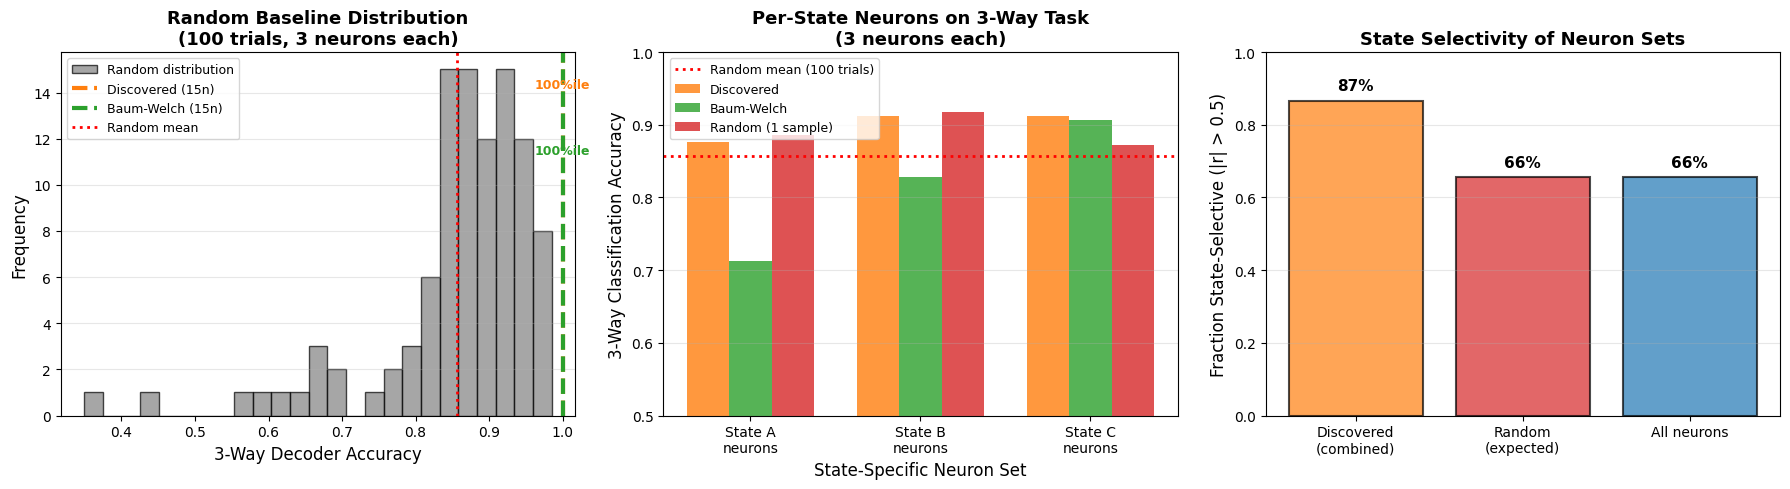


Figure saved to: /content/drive/MyDrive/dales-bp-mech-interp/hmm_gt/random_baseline_analysis_3way.png

Final Interpretation:
✓ Both methods significantly outperform random (>95th percentile)
  → Circuit discovery and correlation-based methods both identify
    functionally superior neuron sets for state decoding
  → Baum-Welch neurons have slight edge (100.00% vs 100.00%)


In [45]:
print("\n" + "=" * 60)
print("Random Baseline Analysis: Why Does Random Work?")
print("=" * 60)

# Run multiple random samples to get distribution of 3-way classification performance
n_trials = 100
random_accs = []

np.random.seed(None)  # Use different seeds
for trial in range(n_trials):
    random_neurons = np.random.choice(model.hidden_size, size=3, replace=False)
    decoder, acc, _ = train_state_decoder(hidden_matrix, belief_labels, random_neurons)
    random_accs.append(acc)

random_accs = np.array(random_accs)

print(f"\nRandom baseline distribution ({n_trials} trials, 3 neurons each):")
print(f"  Task: 3-way classification (A vs B vs C)")
print(f"  Mean accuracy: {random_accs.mean():.2%}")
print(f"  Std dev: {random_accs.std():.3f}")
print(f"  Min: {random_accs.min():.2%}")
print(f"  Max: {random_accs.max():.2%}")
print(f"  Median: {np.median(random_accs):.2%}")
print(f"  25th percentile: {np.percentile(random_accs, 25):.2%}")
print(f"  75th percentile: {np.percentile(random_accs, 75):.2%}")

# Compare to our selection methods
# For per-state comparison: use state-specific neurons on full 3-way task
print("\n" + "=" * 60)
print("Per-State Neuron Sets on 3-Way Classification:")
print("-" * 60)

per_state_results = {}

for state_idx, state_name in enumerate(['A', 'B', 'C']):
    print(f"\nState {state_name} neurons (3-way task):")

    # Discovered neurons for this state
    discovered = maintenance_circuits[state_name]['top_neurons'][:3].numpy()
    decoder_d, acc_d, _ = train_state_decoder(hidden_matrix, belief_labels, discovered)

    # Baum-Welch neurons for this state
    state_corr = correlations[:, state_idx]
    bw_neurons = np.argsort(-np.abs(state_corr))[:3]
    decoder_bw, acc_bw, _ = train_state_decoder(hidden_matrix, belief_labels, bw_neurons)

    # One random sample for comparison
    np.random.seed(42 + state_idx)
    rand_neurons = np.random.choice(model.hidden_size, size=3, replace=False)
    decoder_r, acc_r, _ = train_state_decoder(hidden_matrix, belief_labels, rand_neurons)

    per_state_results[state_name] = {
        'discovered': acc_d,
        'baum_welch': acc_bw,
        'random': acc_r
    }

    print(f"  Discovered: {acc_d:.2%}")
    print(f"  Baum-Welch: {acc_bw:.2%}")
    print(f"  Random (1 sample): {acc_r:.2%}")

    # Compute percentiles
    disc_percentile = (random_accs < acc_d).mean() * 100
    bw_percentile = (random_accs < acc_bw).mean() * 100

    print(f"  Discovered beats {disc_percentile:.0f}% of random samples")
    print(f"  Baum-Welch beats {bw_percentile:.0f}% of random samples")

# Combined circuit comparison
print("\n" + "=" * 60)
print("Combined Circuits on 3-Way Classification:")
print("-" * 60)

comb_disc_acc = results['all_discovered']['accuracy']
comb_bw_acc = results['all_baum_welch']['accuracy']
n_disc = results['all_discovered']['n_neurons']
n_bw = results['all_baum_welch']['n_neurons']

print(f"\nAll discovered neurons ({n_disc} total):  {comb_disc_acc:.2%}")
print(f"All Baum-Welch neurons ({n_bw} total):    {comb_bw_acc:.2%}")
print(f"Random mean (3 neurons):                   {random_accs.mean():.2%}")
print(f"Baseline (all {model.hidden_size} neurons):              {results['all_neurons']['accuracy']:.2%}")

# Compute percentiles for combined
disc_percentile_comb = (random_accs < comb_disc_acc).mean() * 100
bw_percentile_comb = (random_accs < comb_bw_acc).mean() * 100

print(f"\nCombined discovered beats {disc_percentile_comb:.0f}% of random samples")
print(f"Combined Baum-Welch beats {bw_percentile_comb:.0f}% of random samples")

# Analyze why: what fraction of state-selective neurons are in random samples?
print("\n" + "=" * 60)
print("Explanation: State Selectivity in Random Samples")
print("=" * 60)

# From Cell 12, we know which neurons are state-selective
max_corr_per_neuron = np.abs(correlations).max(axis=1)
n_selective = (max_corr_per_neuron > 0.5).sum()

print(f"\nTotal state-selective neurons (|r| > 0.5): {n_selective} / {model.hidden_size}")
print(f"Fraction of network that's state-selective: {n_selective/model.hidden_size:.1%}")
print(f"Probability random sample (3 neurons) includes ≥1 selective: {1 - (1 - n_selective/model.hidden_size)**3:.1%}")

# Expected number of selective neurons in random sample of 3
expected_selective = 3 * (n_selective / model.hidden_size)
print(f"Expected selective neurons in random sample of 3: {expected_selective:.2f}")

# Check how many selective neurons are in discovered vs random
discovered_neurons = results['all_discovered']['neurons']
n_selective_discovered = (max_corr_per_neuron[discovered_neurons] > 0.5).sum()

print(f"\nDiscovered set ({len(discovered_neurons)} neurons):")
print(f"  Contains {n_selective_discovered} state-selective neurons ({n_selective_discovered/len(discovered_neurons)*100:.0f}%)")

# Check distribution of selective neurons in random samples
print(f"\nRandom samples (3 neurons each, 100 trials):")
n_selective_in_random = []
for i in range(100):
    rand_sample = np.random.choice(model.hidden_size, size=3, replace=False)
    n_sel = (max_corr_per_neuron[rand_sample] > 0.5).sum()
    n_selective_in_random.append(n_sel)

n_selective_in_random = np.array(n_selective_in_random)
print(f"  Mean: {n_selective_in_random.mean():.2f} selective neurons")
print(f"  Median: {np.median(n_selective_in_random):.0f} selective neurons")
print(f"  Distribution: {np.bincount(n_selective_in_random, minlength=4)}")
print(f"    (0 selective: {(n_selective_in_random==0).sum()}, 1: {(n_selective_in_random==1).sum()}, "
      f"2: {(n_selective_in_random==2).sum()}, 3: {(n_selective_in_random==3).sum()})")

print("\n" + "=" * 60)
print("Conclusion:")
if n_selective > model.hidden_size * 0.6:
    print(f"Most neurons ({n_selective}/{model.hidden_size} = {n_selective/model.hidden_size:.0%}) encode state information!")
    print("With such dense state encoding, even random 3-neuron samples often work well.")
    print(f"Random samples average ~{expected_selective:.1f} selective neurons.")
    print(f"However, targeted selection achieves {comb_disc_acc:.1%} vs random mean of {random_accs.mean():.1%}.")
else:
    print("Only a subset of neurons encode state information.")
    print("Targeted selection should significantly outperform random sampling.")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Distribution of random accuracies with method comparisons
ax = axes[0]
ax.hist(random_accs, bins=25, alpha=0.7, color='gray', edgecolor='black', label='Random distribution')
ax.axvline(comb_disc_acc, color='#ff7f0e', linewidth=3, label=f'Discovered ({n_disc}n)', linestyle='--')
ax.axvline(comb_bw_acc, color='#2ca02c', linewidth=3, label=f'Baum-Welch ({n_bw}n)', linestyle='--')
ax.axvline(random_accs.mean(), color='red', linewidth=2, label='Random mean', linestyle=':')
ax.set_xlabel('3-Way Decoder Accuracy', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title(f'Random Baseline Distribution\n({n_trials} trials, 3 neurons each)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')

# Add percentile annotations
y_pos = ax.get_ylim()[1] * 0.9
ax.text(comb_disc_acc, y_pos, f'{disc_percentile_comb:.0f}%ile',
        ha='center', fontsize=9, color='#ff7f0e', weight='bold')
ax.text(comb_bw_acc, y_pos * 0.8, f'{bw_percentile_comb:.0f}%ile',
        ha='center', fontsize=9, color='#2ca02c', weight='bold')

# Middle: Per-state comparison (3-way task)
ax = axes[1]
states = ['A', 'B', 'C']
x = np.arange(len(states))
width = 0.25

disc_accs = [per_state_results[s]['discovered'] for s in states]
bw_accs = [per_state_results[s]['baum_welch'] for s in states]
rand_accs_single = [per_state_results[s]['random'] for s in states]

ax.bar(x - width, disc_accs, width, label='Discovered', color='#ff7f0e', alpha=0.8)
ax.bar(x, bw_accs, width, label='Baum-Welch', color='#2ca02c', alpha=0.8)
ax.bar(x + width, rand_accs_single, width, label='Random (1 sample)', color='#d62728', alpha=0.8)
ax.axhline(random_accs.mean(), color='red', linestyle=':', linewidth=2, label='Random mean (100 trials)')

ax.set_xlabel('State-Specific Neuron Set', fontsize=12)
ax.set_ylabel('3-Way Classification Accuracy', fontsize=12)
ax.set_title('Per-State Neurons on 3-Way Task\n(3 neurons each)',
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'State {s}\nneurons' for s in states])
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0.5, 1.0])

# Right: Selectivity comparison
ax = axes[2]
methods = ['Discovered\n(combined)', 'Random\n(expected)', 'All neurons']
selective_fracs = [
    n_selective_discovered / len(discovered_neurons) if len(discovered_neurons) > 0 else 0,
    expected_selective / 3,
    n_selective / model.hidden_size
]
colors = ['#ff7f0e', '#d62728', '#1f77b4']

bars = ax.bar(methods, selective_fracs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Fraction State-Selective (|r| > 0.5)', fontsize=12)
ax.set_title('State Selectivity of Neuron Sets', fontsize=13, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(alpha=0.3, axis='y')

# Add percentage labels
for bar, frac in zip(bars, selective_fracs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{frac*100:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'random_baseline_analysis_3way.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {os.path.join(save_dir, 'random_baseline_analysis_3way.png')}")

# Final interpretation
print("\n" + "=" * 60)
print("Final Interpretation:")
print("=" * 60)

if disc_percentile_comb > 95 and bw_percentile_comb > 95:
    print("✓ Both methods significantly outperform random (>95th percentile)")
    print("  → Circuit discovery and correlation-based methods both identify")
    print("    functionally superior neuron sets for state decoding")
    if comb_disc_acc > comb_bw_acc:
        print(f"  → Discovered neurons have slight edge ({comb_disc_acc:.2%} vs {comb_bw_acc:.2%})")
    else:
        print(f"  → Baum-Welch neurons have slight edge ({comb_bw_acc:.2%} vs {comb_disc_acc:.2%})")
elif disc_percentile_comb > 80:
    print("⚠ Methods moderately outperform random (>80th percentile)")
    print("  → Some functional advantage, but random often works well")
    print("  → High density of state-selective neurons makes random competitive")
else:
    print("✗ Methods do not consistently outperform random")
    print("  → Dense state encoding means most 3-neuron samples work well")

In [46]:
# print("\n" + "=" * 60)
# print("Random Baseline Analysis: Why Does Random Work?")
# print("=" * 60)

# # Run multiple random samples to get distribution
# n_trials = 100
# random_accs = []

# np.random.seed(None)  # Use different seeds
# for trial in range(n_trials):
#     random_neurons = np.random.choice(model.hidden_size, size=3, replace=False)
#     decoder, acc, _ = train_state_decoder(hidden_matrix, belief_labels, random_neurons)
#     random_accs.append(acc)

# random_accs = np.array(random_accs)

# print(f"\nRandom baseline distribution ({n_trials} trials, 3 neurons each):")
# print(f"  Mean accuracy: {random_accs.mean():.2%}")
# print(f"  Std dev: {random_accs.std():.3f}")
# print(f"  Min: {random_accs.min():.2%}")
# print(f"  Max: {random_accs.max():.2%}")
# print(f"  Median: {np.median(random_accs):.2%}")

# # Compare to our discovered neurons
# comb_disc_acc = results['all_discovered']['accuracy']
# comb_bw_acc = results['all_baum_welch']['accuracy']

# print(f"\nComparison to selection methods:")
# print(f"  Discovered accuracy: {comb_disc_acc:.2%}")
# print(f"  Baum-Welch accuracy: {comb_bw_acc:.2%}")
# print(f"  Random mean: {random_accs.mean():.2%}")

# # Compute percentiles
# disc_percentile = (random_accs < comb_disc_acc).mean() * 100
# bw_percentile = (random_accs < comb_bw_acc).mean() * 100

# print(f"\nDiscovered neurons beat {disc_percentile:.0f}% of random samples")
# print(f"Baum-Welch neurons beat {bw_percentile:.0f}% of random samples")

# if disc_percentile > 90:
#     print("\n✓ Discovered neurons significantly outperform random (top 10%)")
# elif disc_percentile > 70:
#     print("\n⚠ Discovered neurons moderately outperform random (top 30%)")
# elif disc_percentile > 50:
#     print("\n⚠ Discovered neurons slightly better than random")
# else:
#     print("\n✗ Discovered neurons are not better than random")

# # Analyze why: what fraction of state-selective neurons are in random samples?
# print("\n" + "=" * 60)
# print("Explanation: State Selectivity in Random Samples")
# print("=" * 60)

# # From Cell 12, we know which neurons are state-selective
# max_corr_per_neuron = np.abs(correlations).max(axis=1)
# n_selective = (max_corr_per_neuron > 0.5).sum()

# print(f"\nTotal state-selective neurons (|r| > 0.5): {n_selective} / {model.hidden_size}")
# print(f"Probability random sample includes ≥1 selective: {1 - (1 - n_selective/model.hidden_size)**3:.1%}")

# # Expected number of selective neurons in random sample of 3
# expected_selective = 3 * (n_selective / model.hidden_size)
# print(f"Expected selective neurons in random sample of 3: {expected_selective:.1f}")

# # Check how many selective neurons are in discovered vs random
# discovered_neurons = results['all_discovered']['neurons']
# n_selective_discovered = (max_corr_per_neuron[discovered_neurons] > 0.5).sum()

# print(f"\nDiscovered set ({len(discovered_neurons)} neurons):")
# print(f"  Contains {n_selective_discovered} state-selective neurons ({n_selective_discovered/len(discovered_neurons)*100:.0f}%)")

# # Check a few random samples
# print(f"\nRandom samples (3 neurons each):")
# for i in range(5):
#     rand_sample = np.random.choice(model.hidden_size, size=3, replace=False)
#     n_sel = (max_corr_per_neuron[rand_sample] > 0.5).sum()
#     print(f"  Sample {i+1}: {n_sel} selective neurons ({n_sel/3*100:.0f}%)")

# print("\n" + "=" * 60)
# print("Conclusion:")
# if n_selective > model.hidden_size * 0.6:
#     print(f"Most neurons ({n_selective}/{model.hidden_size}) encode state information!")
#     print("With only 3 neurons, targeted selection becomes more critical.")
#     print("Random samples have ~{:.1f} selective neurons on average.".format(expected_selective))
# else:
#     print("Only a subset of neurons encode state information.")
#     print("Circuit discovery should significantly outperform random sampling.")

# # Visualize
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# # Left: Distribution of random accuracies
# ax = axes[0]
# ax.hist(random_accs, bins=20, alpha=0.7, color='gray', edgecolor='black')
# ax.axvline(comb_disc_acc, color='#ff7f0e', linewidth=3, label='Discovered', linestyle='--')
# ax.axvline(comb_bw_acc, color='#2ca02c', linewidth=3, label='Baum-Welch', linestyle='--')
# ax.axvline(random_accs.mean(), color='red', linewidth=2, label='Random mean', linestyle=':')
# ax.set_xlabel('Decoder Accuracy', fontsize=12)
# ax.set_ylabel('Frequency', fontsize=12)
# ax.set_title(f'Random Baseline Distribution\n({n_trials} trials, 3 neurons each)',
#              fontsize=13, fontweight='bold')
# ax.legend()
# ax.grid(alpha=0.3, axis='y')

# # Right: Selectivity comparison
# ax = axes[1]
# methods = ['Discovered', 'Random\n(expected)', 'All neurons']
# selective_fracs = [
#     n_selective_discovered / len(discovered_neurons) if len(discovered_neurons) > 0 else 0,
#     expected_selective / 3,
#     n_selective / model.hidden_size
# ]
# colors = ['#ff7f0e', '#d62728', '#1f77b4']

# bars = ax.bar(methods, selective_fracs, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
# ax.set_ylabel('Fraction State-Selective (|r| > 0.5)', fontsize=12)
# ax.set_title('State Selectivity of Neuron Sets', fontsize=13, fontweight='bold')
# ax.set_ylim([0, 1])
# ax.grid(alpha=0.3, axis='y')

# # Add percentage labels
# for bar, frac in zip(bars, selective_fracs):
#     height = bar.get_height()
#     ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
#             f'{frac*100:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# plt.tight_layout()
# plt.savefig(os.path.join(save_dir, 'random_baseline_analysis.png'), dpi=150, bbox_inches='tight')
# plt.show()

# print(f"\nFigure saved to: {os.path.join(save_dir, 'random_baseline_analysis.png')}")

#### Temporal specificity

Temporal Specificity: When Are Neurons Important?


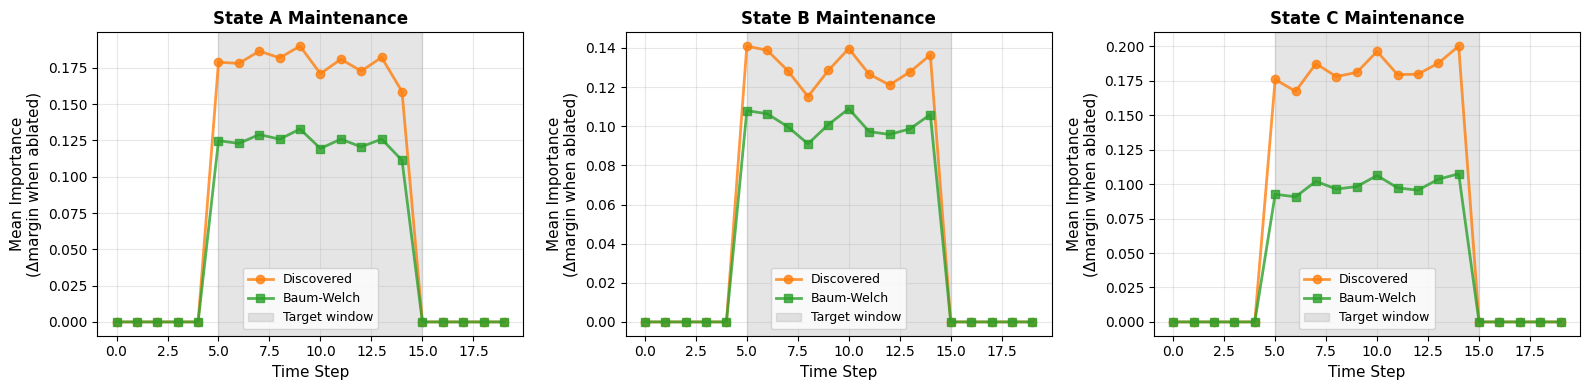


Temporal Concentration (importance in target window vs outside):
------------------------------------------------------------

State A:
  Discovered: in-window=0.178, out-window=0.000, ratio=178109.99x
  Baum-Welch: in-window=0.124, out-window=0.000, ratio=123892.31x
  → Discovered neurons more temporally specific!

State B:
  Discovered: in-window=0.130, out-window=0.000, ratio=130354.92x
  Baum-Welch: in-window=0.101, out-window=0.000, ratio=101264.08x
  → Discovered neurons more temporally specific!

State C:
  Discovered: in-window=0.183, out-window=0.000, ratio=183353.98x
  Baum-Welch: in-window=0.099, out-window=0.000, ratio=99045.75x
  → Discovered neurons more temporally specific!

Interpretation:
If discovered neurons have higher in-window/out-window ratios:
  → Causal methods identify neurons active specifically when needed
  → Correlation methods may find 'always-on' state indicators


In [47]:
print("=" * 60)
print("Temporal Specificity: When Are Neurons Important?")
print("=" * 60)

# For each state, compute time-resolved importance during maintenance vs transition

def compute_temporal_importance(analyzer, state_name, pattern_type='maintain'):
    """Compute per-neuron, per-timestep importance."""

    if pattern_type == 'maintain':
        pattern = diagnostic_patterns[f'maintain_{state_name}']
        window_start, window_end = 5, 15
    else:  # transition
        # Use transition TO this state
        if state_name == 'A':
            pattern = diagnostic_patterns['transition_C_to_A']
        elif state_name == 'B':
            pattern = diagnostic_patterns['transition_A_to_B']
        else:
            pattern = diagnostic_patterns['transition_B_to_C']
        mid = pattern['obs_onehot'].shape[1] // 2
        window_start, window_end = mid - 2, mid + 3

    base_run = analyzer.run_and_record(pattern['obs_onehot'])

    # Get discovered neurons for this state
    discovered = maintenance_circuits[state_name]['top_neurons'][:3].numpy()

    # Get Baum-Welch neurons
    state_idx = ['A', 'B', 'C'].index(state_name)
    state_corr = correlations[:, state_idx]
    bw_neurons = np.argsort(-np.abs(state_corr))[:3]

    # Compute importance over time for both sets
    T = base_run['hidden'].shape[1]
    discovered_importance_over_time = np.zeros(T)
    bw_importance_over_time = np.zeros(T)

    base_margin = analyzer._prediction_margin(base_run['logits'])

    # For each timestep, ablate and measure drop
    for t in range(window_start, window_end):
        # Ablate discovered neurons at timestep t
        for n in discovered:
            patched = base_run['hidden'].clone()
            patched[:, t, n] *= 0.05
            out = analyzer.rollout_with_patch(base_run, patched, time_window=(t, t+1))
            patched_margin = analyzer._prediction_margin(out['logits'])
            discovered_importance_over_time[t] += (base_margin[:, t] - patched_margin[:, t]).mean().item()

        # Ablate BW neurons at timestep t
        for n in bw_neurons:
            patched = base_run['hidden'].clone()
            patched[:, t, n] *= 0.05
            out = analyzer.rollout_with_patch(base_run, patched, time_window=(t, t+1))
            patched_margin = analyzer._prediction_margin(out['logits'])
            bw_importance_over_time[t] += (base_margin[:, t] - patched_margin[:, t]).mean().item()

    # Normalize by number of neurons
    discovered_importance_over_time /= len(discovered)
    bw_importance_over_time /= len(bw_neurons)

    return discovered_importance_over_time, bw_importance_over_time, (window_start, window_end)

# Analyze for each state
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for state_idx, state_name in enumerate(['A', 'B', 'C']):
    ax = axes[state_idx]

    # Maintenance period
    disc_maint, bw_maint, window = compute_temporal_importance(
        analyzer, state_name, pattern_type='maintain'
    )

    # Plot
    times = np.arange(len(disc_maint))
    ax.plot(times, disc_maint, 'o-', color='#ff7f0e', linewidth=2,
            markersize=6, label='Discovered', alpha=0.8)
    ax.plot(times, bw_maint, 's-', color='#2ca02c', linewidth=2,
            markersize=6, label='Baum-Welch', alpha=0.8)

    # Highlight maintenance window
    ax.axvspan(window[0], window[1], alpha=0.2, color='gray', label='Target window')

    ax.set_xlabel('Time Step', fontsize=11)
    ax.set_ylabel('Mean Importance\n(Δmargin when ablated)', fontsize=11)
    ax.set_title(f'State {state_name} Maintenance', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'temporal_specificity.png'), dpi=150, bbox_inches='tight')
plt.show()

# Compute concentration metric: how concentrated is importance in target window?
print("\nTemporal Concentration (importance in target window vs outside):")
print("-" * 60)

for state_name in ['A', 'B', 'C']:
    disc_imp, bw_imp, (ws, we) = compute_temporal_importance(analyzer, state_name, 'maintain')

    # Inside vs outside window
    disc_in = disc_imp[ws:we].mean()
    disc_out = np.concatenate([disc_imp[:ws], disc_imp[we:]]).mean() if ws > 0 or we < len(disc_imp) else 0

    bw_in = bw_imp[ws:we].mean()
    bw_out = np.concatenate([bw_imp[:ws], bw_imp[we:]]).mean() if ws > 0 or we < len(bw_imp) else 0

    disc_ratio = disc_in / (disc_out + 1e-6)
    bw_ratio = bw_in / (bw_out + 1e-6)

    print(f"\nState {state_name}:")
    print(f"  Discovered: in-window={disc_in:.3f}, out-window={disc_out:.3f}, ratio={disc_ratio:.2f}x")
    print(f"  Baum-Welch: in-window={bw_in:.3f}, out-window={bw_out:.3f}, ratio={bw_ratio:.2f}x")

    if disc_ratio > bw_ratio * 1.2:
        print(f"  → Discovered neurons more temporally specific!")
    elif bw_ratio > disc_ratio * 1.2:
        print(f"  → Baum-Welch neurons more temporally specific")
    else:
        print(f"  → Similar temporal profiles")

print("\n" + "=" * 60)
print("Interpretation:")
print("If discovered neurons have higher in-window/out-window ratios:")
print("  → Causal methods identify neurons active specifically when needed")
print("  → Correlation methods may find 'always-on' state indicators")

#### Functional specificity

In [48]:
print("=" * 60)
print("Functional Specificity: Maintenance vs Transition Circuits")
print("=" * 60)

# Key question: Are discovered neurons functionally specific to maintenance?
# Do transition circuits overlap with maintenance circuits?

# Get transition circuits
transition_results = {}

print("\nDiscovering transition circuits...")
for from_state, to_state in [('A', 'B'), ('B', 'C'), ('C', 'A')]:
    trans_circuit = analyzer.find_state_transition_circuit(from_state, to_state, verbose=False)
    transition_results[f"{from_state}_to_{to_state}"] = trans_circuit
    print(f"  {from_state}→{to_state}: {trans_circuit['top_neurons'][:tk].tolist()}")

# Compare overlap: maintenance vs transition circuits
print("\n" + "=" * 60)
print("Circuit Overlap Analysis:")
print("-" * 60)

for state_name in ['A', 'B', 'C']:
    maint_neurons = set(maintenance_circuits[state_name]['top_neurons'][:tk].numpy())

    # Find transitions involving this state
    if state_name == 'A':
        trans_from = set(transition_results['A_to_B']['top_neurons'][:tk].numpy())
        trans_to = set(transition_results['C_to_A']['top_neurons'][:tk].numpy())
    elif state_name == 'B':
        trans_from = set(transition_results['B_to_C']['top_neurons'][:tk].numpy())
        trans_to = set(transition_results['A_to_B']['top_neurons'][:tk].numpy())
    else:
        trans_from = set(transition_results['C_to_A']['top_neurons'][:tk].numpy())
        trans_to = set(transition_results['B_to_C']['top_neurons'][:tk].numpy())

    overlap_from = maint_neurons & trans_from
    overlap_to = maint_neurons & trans_to

    print(f"\nState {state_name}:")
    print(f"  Maintenance neurons: {sorted(maint_neurons)}")
    print(f"  Transition FROM {state_name}: {sorted(trans_from)}")
    print(f"    Overlap: {sorted(overlap_from)} ({len(overlap_from)}/tk)")
    print(f"  Transition TO {state_name}: {sorted(trans_to)}")
    print(f"    Overlap: {sorted(overlap_to)} ({len(overlap_to)}/tk)")

    if len(overlap_from) == 0 and len(overlap_to) == 0:
        print(f"  → Maintenance circuit is distinct from transition circuits!")

# Hypothesis: If discovered neurons show low overlap between maintenance and transition,
# this suggests functional specificity that correlation-based methods wouldn't capture

print("\n" + "=" * 60)
print("Interpretation:")
print("Low overlap between maintenance and transition circuits suggests:")
print("  - Causal discovery identifies functionally specialized subcircuits")
print("  - Correlation methods would miss this temporal/functional structure")
print("  - Different neurons are recruited for different computational demands")

Functional Specificity: Maintenance vs Transition Circuits

Discovering transition circuits...
  A→B: [64, 84, 53, 88, 113]
  B→C: [30, 2, 118, 72, 71]
  C→A: [45, 90, 96, 105, 24]

Circuit Overlap Analysis:
------------------------------------------------------------

State A:
  Maintenance neurons: [np.int64(8), np.int64(45), np.int64(86), np.int64(90), np.int64(105)]
  Transition FROM A: [np.int64(53), np.int64(64), np.int64(84), np.int64(88), np.int64(113)]
    Overlap: [] (0/tk)
  Transition TO A: [np.int64(24), np.int64(45), np.int64(90), np.int64(96), np.int64(105)]
    Overlap: [np.int64(45), np.int64(90), np.int64(105)] (3/tk)

State B:
  Maintenance neurons: [np.int64(3), np.int64(63), np.int64(64), np.int64(77), np.int64(88)]
  Transition FROM B: [np.int64(2), np.int64(30), np.int64(71), np.int64(72), np.int64(118)]
    Overlap: [] (0/tk)
  Transition TO B: [np.int64(53), np.int64(64), np.int64(84), np.int64(88), np.int64(113)]
    Overlap: [np.int64(64), np.int64(88)] (2/tk

#### Robustness to noise

Robustness Analysis: Performance Under Noise


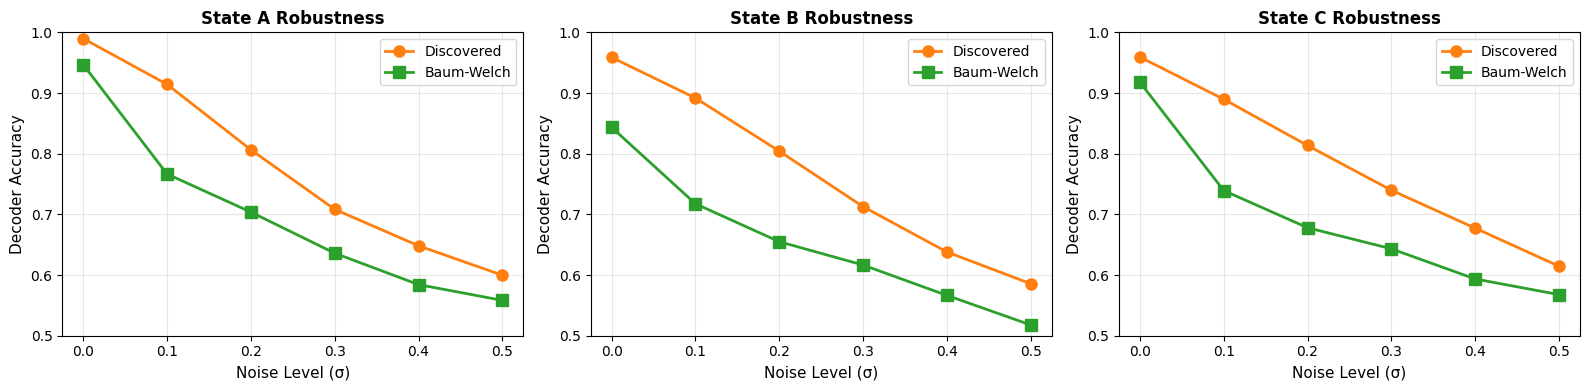


Robustness Summary:
If discovered neurons degrade more gracefully under noise:
  → Causal methods identify functionally robust representations
  → These neurons may be more critical to actual computation


In [49]:
print("=" * 60)
print("Robustness Analysis: Performance Under Noise")
print("=" * 60)

# Test: If we corrupt hidden states with noise, do discovered neurons remain functionally relevant?

def test_robustness_to_noise(neuron_set, noise_levels=[0.0, 0.1, 0.2, 0.3, 0.4]):
    """Test decoder performance as we add noise to hidden states."""

    accuracies = []

    for noise_level in noise_levels:
        # Add Gaussian noise to hidden states
        noisy_hidden = hidden_matrix + np.random.randn(*hidden_matrix.shape) * noise_level

        # Train decoder on noisy data
        decoder, acc, _ = train_state_decoder(noisy_hidden, belief_labels, neuron_set)
        accuracies.append(acc)

    return accuracies

# Test robustness for each state
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for state_idx, state_name in enumerate(['A', 'B', 'C']):
    ax = axes[state_idx]

    # Get neuron sets
    discovered = maintenance_circuits[state_name]['top_neurons'][:tk].numpy()
    state_corr = correlations[:, state_idx]
    bw_neurons = np.argsort(-np.abs(state_corr))[:tk]

    # Test robustness
    disc_accs = test_robustness_to_noise(discovered, noise_levels)
    bw_accs = test_robustness_to_noise(bw_neurons, noise_levels)

    # Plot
    ax.plot(noise_levels, disc_accs, 'o-', color='#ff7f0e', linewidth=2,
            markersize=8, label='Discovered')
    ax.plot(noise_levels, bw_accs, 's-', color='#2ca02c', linewidth=2,
            markersize=8, label='Baum-Welch')

    ax.set_xlabel('Noise Level (σ)', fontsize=11)
    ax.set_ylabel('Decoder Accuracy', fontsize=11)
    ax.set_title(f'State {state_name} Robustness', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim([0.5, 1.0])

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'robustness_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\nRobustness Summary:")
print("If discovered neurons degrade more gracefully under noise:")
print("  → Causal methods identify functionally robust representations")
print("  → These neurons may be more critical to actual computation")